In [1]:
# =============================================================================
# CELL 1 — IMPORTS
# =============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from scipy.optimize import minimize

In [2]:
# =============================================================================
# CELL 2 — DATA
# Train/test split enforced at data fetch level
# TRAIN: 2012-05-18 → 2022-12-31 (daily bars, MLE + cointegration only)
# TEST:  2023-01-01 → today      (daily bars, backtest only)
# No test data is ever touched during training steps
# =============================================================================

TRAIN_START = "2012-05-18"   # META IPO date
TRAIN_END   = "2022-12-31"
TEST_START  = "2023-01-01"
TEST_END    = datetime.datetime.today().strftime("%Y-%m-%d")

# --- Training data ---
meta_train_raw = yf.download("META", start=TRAIN_START, end=TRAIN_END,
                              auto_adjust=True, progress=False)["Close"].squeeze()
qqq_train_raw  = yf.download("QQQ",  start=TRAIN_START, end=TRAIN_END,
                              auto_adjust=True, progress=False)["Close"].squeeze()

train          = pd.concat([meta_train_raw, qqq_train_raw], axis=1).dropna()
train.columns  = ["META", "QQQ"]
meta_tr        = train["META"].values.astype(float)
qqq_tr         = train["QQQ"].values.astype(float)

# --- Test data ---
meta_test_raw  = yf.download("META", start=TEST_START, end=TEST_END,
                              auto_adjust=True, progress=False)["Close"].squeeze()
qqq_test_raw   = yf.download("QQQ",  start=TEST_START, end=TEST_END,
                              auto_adjust=True, progress=False)["Close"].squeeze()

test           = pd.concat([meta_test_raw, qqq_test_raw], axis=1).dropna()
test.columns   = ["META", "QQQ"]
meta_te        = test["META"].values.astype(float)
qqq_te         = test["QQQ"].values.astype(float)

print("=== Data Summary ===")
print(f"Train: {train.index[0].date()} → {train.index[-1].date()} "
      f"({len(train)} bars, {len(train)/252:.1f} years)")
print(f"Test:  {test.index[0].date()} → {test.index[-1].date()} "
      f"({len(test)} bars, {len(test)/252:.1f} years)")
print(f"\nTrain META: ${meta_tr[0]:.2f} → ${meta_tr[-1]:.2f}")
print(f"Train QQQ:  ${qqq_tr[0]:.2f} → ${qqq_tr[-1]:.2f}")
print(f"Test  META: ${meta_te[0]:.2f} → ${meta_te[-1]:.2f}")
print(f"Test  QQQ:  ${qqq_te[0]:.2f} → ${qqq_te[-1]:.2f}")

=== Data Summary ===
Train: 2012-05-18 → 2022-12-30 (2673 bars, 10.6 years)
Test:  2023-01-03 → 2026-04-28 (832 bars, 3.3 years)

Train META: $37.93 → $119.40
Train QQQ:  $53.86 → $261.23
Test  META: $123.77 → $671.34
Test  QQQ:  $259.47 → $657.55


In [3]:
# =============================================================================
# CELL 3 — KALMAN FILTER
# =============================================================================
# Run on TRAIN data for MLE calibration (Cell 4)
# Run on TEST data for backtest (Cell 6)
# Parameters flow one way only: train → test
# =============================================================================

def kalman_filter(meta, qqq, delta=1e-4, Ve=0.001):
    """
    Kalman Filter for dynamic hedge ratio estimation.
    State vector: [β₀, β₁] where META_t = β₀ + β₁·QQQ_t + ε_t
    """
    n  = len(meta)
    Vw = delta / (1 - delta) * np.eye(2)

    beta = np.zeros((n, 2))
    P    = np.zeros((n, 2, 2))
    e    = np.zeros(n)
    Q    = np.zeros(n)

    beta[0] = [0, 1]
    P[0]    = np.eye(2)

    for t in range(1, n):
        F         = np.array([1.0, qqq[t]])
        beta_pred = beta[t-1]
        P_pred    = P[t-1] + Vw

        e[t] = meta[t] - F @ beta_pred
        Q[t] = F @ P_pred @ F + Ve

        K       = (P_pred @ F) / Q[t]
        beta[t] = beta_pred + K * e[t]
        P[t]    = P_pred - np.outer(K, F) @ P_pred

    return beta, e, Q

# Run on training data — used for MLE calibration only
beta_tr, e_tr, Q_tr = kalman_filter(meta_tr, qqq_tr)

print("=== Kalman Filter — Training Data (default params) ===")
print(f"β₁ mean:  {beta_tr[:,1].mean():.4f}")
print(f"β₁ std:   {beta_tr[:,1].std():.4f}")
print(f"β₁ range: [{beta_tr[:,1].min():.4f}, {beta_tr[:,1].max():.4f}]")
print(f"\nSpread stats (train):")
print(pd.Series(e_tr).describe().round(4))

=== Kalman Filter — Training Data (default params) ===
β₁ mean:  0.8800
β₁ std:   0.2475
β₁ range: [0.2818, 1.2711]

Spread stats (train):
count    2673.0000
mean       -0.0616
std         3.0158
min       -71.4817
25%        -0.8848
50%        -0.0440
75%         0.8554
max        24.2736
dtype: float64


In [4]:
# =============================================================================
# CELL 4 — COINTEGRATION TESTING (TRAIN ONLY)
# =============================================================================
# All tests run on training data only
# Results inform methodology but do not touch test data
# =============================================================================

# 4A — ADF on individual train series
adf_meta_tr = adfuller(meta_tr, autolag="AIC")
adf_qqq_tr  = adfuller(qqq_tr,  autolag="AIC")

print("=== 4A — ADF: Individual Price Series (Train) ===")
print(f"META — p: {adf_meta_tr[1]:.4f}, "
      f"non-stationary: {adf_meta_tr[1] > 0.05}")
print(f"QQQ  — p: {adf_qqq_tr[1]:.4f},  "
      f"non-stationary: {adf_qqq_tr[1] > 0.05}")

# 4B — Engle-Granger
eg_stat, eg_pval, eg_crit = coint(meta_tr, qqq_tr)

print("\n=== 4B — Engle-Granger Cointegration Test (Train) ===")
print(f"Stat: {eg_stat:.4f}, p-value: {eg_pval:.4f}")
print(f"Critical values — 1%: {eg_crit[0]:.4f}, "
      f"5%: {eg_crit[1]:.4f}, 10%: {eg_crit[2]:.4f}")
print(f"Cointegrated at 5%: {eg_pval < 0.05}")

# 4C — Johansen
joh = coint_johansen(train[["META", "QQQ"]], det_order=0, k_ar_diff=1)

print("\n=== 4C — Johansen Cointegration Test (Train) ===")
print(f"r=0 — stat: {joh.lr1[0]:.4f}, "
      f"95% crit: {joh.cvt[0,1]:.4f}, "
      f"reject: {joh.lr1[0] > joh.cvt[0,1]}")
print(f"r=1 — stat: {joh.lr1[1]:.4f}, "
      f"95% crit: {joh.cvt[1,1]:.4f}, "
      f"reject: {joh.lr1[1] > joh.cvt[1,1]}")

# 4D — OLS spread half-life on training data
A        = np.vstack([np.ones(len(meta_tr)), qqq_tr]).T
coeffs   = np.linalg.lstsq(A, meta_tr, rcond=None)[0]
beta_ols = coeffs[1]

ols_spread = meta_tr - (coeffs[0] + beta_ols * qqq_tr)
ols_series = pd.Series(ols_spread, index=train.index)
adf_ols    = adfuller(ols_spread, autolag="AIC")

s_lag  = ols_series.shift(1).dropna()
s_diff = ols_series.diff().dropna()
phi    = np.polyfit(s_lag.values, s_diff.values, 1)[0]

print("\n=== 4D — OLS Spread + Half-Life (Train) ===")
print(f"ADF p-value:      {adf_ols[1]:.4f} — "
      f"stationary: {adf_ols[1] < 0.05}")
print(f"OLS hedge ratio:  {beta_ols:.4f} (fixed — train period mean)")

if -1 < phi < 0:
    hl = -np.log(2) / np.log(1 + phi)
    print(f"Half-life:        {hl:.1f} days")
    print(f"Rolling window:   {int(hl * 2)} days "
          f"(2 × half-life rule)")
else:
    hl = None
    print(f"φ = {phi:.4f} — no clean OU mean reversion")

# 4E — Kalman spread stationarity on training data
adf_kalman_tr = adfuller(e_tr[10:], autolag="AIC")

print("\n=== 4E — Kalman Spread Stationarity (Train) ===")
print(f"ADF stat:  {adf_kalman_tr[0]:.4f}")
print(f"P-value:   {adf_kalman_tr[1]:.4f} — "
      f"stationary: {adf_kalman_tr[1] < 0.05}")

# Summary
print("\n=== Cointegration Suite Summary ===")
print(f"{'Test':<35} {'Result':<15} {'Interpretation'}")
print("-" * 70)
print(f"{'ADF — META (train)':<35} "
      f"{'p='+str(round(adf_meta_tr[1],3)):<15} Non-stationary ✓")
print(f"{'ADF — QQQ (train)':<35} "
      f"{'p='+str(round(adf_qqq_tr[1],3)):<15} Non-stationary ✓")
print(f"{'Engle-Granger (train)':<35} "
      f"{'p='+str(round(eg_pval,3)):<15} "
      f"{'Cointegrated ✓' if eg_pval < 0.05 else 'Not cointegrated'}")
print(f"{'Johansen (train)':<35} "
      f"{'Reject r=0' if joh.lr1[0] > joh.cvt[0,1] else 'Fails 95%':<15} "
      f"{'Cointegrated ✓' if joh.lr1[0] > joh.cvt[0,1] else 'Not cointegrated'}")
print(f"{'ADF — OLS spread (train)':<35} "
      f"{'p='+str(round(adf_ols[1],3)):<15} "
      f"{'Stationary ✓' if adf_ols[1] < 0.05 else 'Non-stationary'}")
if hl:
    print(f"{'Half-life (train)':<35} "
          f"{str(round(hl,1))+' days':<15} "
          f"Rolling window → {int(hl*2)} days")
print(f"{'ADF — Kalman spread (train)':<35} "
      f"{'p='+str(round(adf_kalman_tr[1],4)):<15} "
      f"{'Stationary ✓✓' if adf_kalman_tr[1] < 0.05 else 'Non-stationary'}")

=== 4A — ADF: Individual Price Series (Train) ===
META — p: 0.4959, non-stationary: True
QQQ  — p: 0.8268,  non-stationary: True

=== 4B — Engle-Granger Cointegration Test (Train) ===
Stat: -1.1209, p-value: 0.8774
Critical values — 1%: -3.9005, 5%: -3.3384, 10%: -3.0460
Cointegrated at 5%: False

=== 4C — Johansen Cointegration Test (Train) ===
r=0 — stat: 12.2465, 95% crit: 15.4943, reject: False
r=1 — stat: 3.8627, 95% crit: 3.8415, reject: True

=== 4D — OLS Spread + Half-Life (Train) ===
ADF p-value:      0.7070 — stationary: False
OLS hedge ratio:  0.8320 (fixed — train period mean)
Half-life:        398.3 days
Rolling window:   796 days (2 × half-life rule)

=== 4E — Kalman Spread Stationarity (Train) ===
ADF stat:  -21.1253
P-value:   0.0000 — stationary: True

=== Cointegration Suite Summary ===
Test                                Result          Interpretation
----------------------------------------------------------------------
ADF — META (train)                  p=0.496   

In [5]:
# =============================================================================
# CELL 5 — MLE CALIBRATION (TRAIN ONLY)
# =============================================================================
# Optimise δ and Ve on training data only
# These parameters are then frozen and applied to test data
# Bounded optimisation to prevent degenerate solutions (Ve → 0)
# =============================================================================

def kalman_loglik(params, meta, qqq):
    """
    Negative log-likelihood of Kalman filter.
    params = [delta, Ve] in natural space with bounds.
    """
    delta = np.clip(params[0], 1e-8, 0.9999)
    Ve    = params[1]

    n  = len(meta)
    Vw = delta / (1 - delta) * np.eye(2)

    beta    = np.zeros((n, 2))
    P       = np.zeros((n, 2, 2))
    log_lik = 0.0

    beta[0] = [0, 1]
    P[0]    = np.eye(2)

    for t in range(1, n):
        F         = np.array([1.0, qqq[t]])
        beta_pred = beta[t-1]
        P_pred    = P[t-1] + Vw

        e_t = meta[t] - F @ beta_pred
        Q_t = F @ P_pred @ F + Ve

        if Q_t <= 0:
            continue

        log_lik += -0.5 * (np.log(Q_t) + e_t**2 / Q_t)

        K       = (P_pred @ F) / Q_t
        beta[t] = beta_pred + K * e_t
        P[t]    = P_pred - np.outer(K, F) @ P_pred

    return -log_lik

# Bounds — Ve minimum 0.01 prevents degenerate zero-noise solution
bounds = [(1e-6, 0.01), (0.01, 100.0)]
x0     = [1e-4, 0.1]

result = minimize(
    kalman_loglik,
    x0,
    args=(meta_tr, qqq_tr),
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 10000, "ftol": 1e-12, "gtol": 1e-8}
)

delta_mle = result.x[0]
Ve_mle    = result.x[1]

print("=== MLE Calibration Results (Train: 2012-2023) ===")
print(f"Converged:  {result.success}")
print(f"Message:    {result.message}")
print(f"\n{'Parameter':<10} {'Value':<15} {'Bounds'}")
print("-" * 35)
print(f"{'delta':<10} {delta_mle:.4e}     [1e-6, 0.01]")
print(f"{'Ve':<10} {Ve_mle:.4e}     [0.01, 100]")

# Verify on training spread
beta_tr_mle, e_tr_mle, _ = kalman_filter(
    meta_tr, qqq_tr, delta=delta_mle, Ve=Ve_mle)

adf_tr_mle = adfuller(e_tr_mle[10:], autolag="AIC")
print(f"\n=== Train Spread Stationarity (MLE params) ===")
print(f"ADF p-value: {adf_tr_mle[1]:.4f} — "
      f"stationary: {adf_tr_mle[1] < 0.05}")
print(f"β₁ mean: {beta_tr_mle[:,1].mean():.4f}")
print(f"β₁ std:  {beta_tr_mle[:,1].std():.4f}")

# =============================================================================
# PARAMETERS ARE NOW FROZEN
# delta_mle and Ve_mle will not change from this point forward
# All subsequent cells use these values on test data only
# =============================================================================
print(f"\n{'='*40}")
print(f"FROZEN PARAMETERS FOR TEST SET:")
print(f"  delta = {delta_mle:.4e}")
print(f"  Ve    = {Ve_mle:.4e}")
print(f"{'='*40}")

=== MLE Calibration Results (Train: 2012-2023) ===
Converged:  True
Message:    CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Parameter  Value           Bounds
-----------------------------------
delta      2.1246e-04     [1e-6, 0.01]
Ve         1.0000e-02     [0.01, 100]

=== Train Spread Stationarity (MLE params) ===
ADF p-value: 0.0000 — stationary: True
β₁ mean: 0.8770
β₁ std:  0.2449

FROZEN PARAMETERS FOR TEST SET:
  delta = 2.1246e-04
  Ve    = 1.0000e-02


In [8]:
# =============================================================================
# CELL 6 — TEST SET: KALMAN FILTER + VOL-SCALED Z-SCORE
# =============================================================================
# Frozen parameters from Cell 5 applied to test data only
# No parameter touching from this point forward
#
# VOL-SCALED ENTRY THRESHOLD:
# threshold_t = k × rolling_std(zscore, vol_window)
# When vol is high → threshold rises → harder to enter → fewer trades
# When vol is low  → threshold falls → easier to enter → more trades
# =============================================================================

# -----------------------------------------------------------------------------
# 6A — KALMAN FILTER ON TEST DATA
# -----------------------------------------------------------------------------
beta_te, e_te, Q_te = kalman_filter(
    meta_te, qqq_te,
    delta=delta_mle,   # frozen from Cell 5
    Ve=Ve_mle          # frozen from Cell 5
)

# Verify test spread stationarity — should hold out of sample
adf_te = adfuller(e_te[10:], autolag="AIC")
print("=== 6A — Test Spread Stationarity ===")
print(f"ADF p-value: {adf_te[1]:.4f} — "
      f"stationary: {adf_te[1] < 0.05}")
print(f"β₁ mean:  {beta_te[:,1].mean():.4f}")
print(f"β₁ std:   {beta_te[:,1].std():.4f}")
print(f"β₁ range: [{beta_te[:,1].min():.4f}, {beta_te[:,1].max():.4f}]")

# -----------------------------------------------------------------------------
# 6B — MAD Z-SCORE ON TEST SPREAD
# Window = 60 days (3 months) — practical choice given 398-day half-life
# means OLS-based window selection is not applicable here
# -----------------------------------------------------------------------------
def rolling_mad_zscore(spread, window):
    """
    Robust z-score using median and MAD.
    Scaled by 1.4826 to match std under Gaussian assumptions.
    """
    median = spread.rolling(window).median()
    mad    = (spread - median).abs().rolling(window).median() * 1.4826
    return (spread - median) / mad

spread_te = pd.Series(e_te, index=test.index)
window    = 60   # 3 months of daily bars

zscore    = rolling_mad_zscore(spread_te, window)
zscore    = zscore.clip(-4, 4)

print("\n=== 6B — Z-Score Stats (Test) ===")
print(zscore.describe().round(4))
print(f"\nBars beyond ±1: {(zscore.abs() > 1).sum()} / "
      f"{zscore.notna().sum()}")
print(f"Bars beyond ±2: {(zscore.abs() > 2).sum()} / "
      f"{zscore.notna().sum()}")

# -----------------------------------------------------------------------------
# 6C — VOL-SCALED ENTRY THRESHOLD
# threshold_t = k × rolling_std(zscore, vol_window)
# vol_window  = 20 days (1 month) — responsive but not noisy
# k           = 1.5 — tighter than fixed ±2, more selective
# -----------------------------------------------------------------------------
k          = 1.5
vol_window = 20

zscore_vol    = zscore.rolling(vol_window).std()
threshold     = k * zscore_vol

# Clip threshold to reasonable range
# Minimum 0.5 — never enter on tiny moves
# Maximum 2.5 — never require extreme moves to enter
threshold     = threshold.clip(0.5, 2.5)

print("\n=== 6C — Vol-Scaled Threshold Stats ===")
print(threshold.describe().round(4))
print(f"\nMean threshold:   {threshold.mean():.4f}")
print(f"Min threshold:    {threshold.min():.4f}")
print(f"Max threshold:    {threshold.max():.4f}")
print(f"\nFor reference — fixed threshold would be: 2.0")
print(f"Vol-scaled mean:  {threshold.mean():.4f} "
      f"({'tighter' if threshold.mean() < 2.0 else 'looser'} than fixed)")

=== 6A — Test Spread Stationarity ===
ADF p-value: 0.0000 — stationary: True
β₁ mean:  1.0279
β₁ std:   0.2121
β₁ range: [0.4840, 1.3788]

=== 6B — Z-Score Stats (Test) ===
count    714.0000
mean       0.0386
std        1.2072
min       -4.0000
25%       -0.6820
50%        0.0031
75%        0.7182
max        4.0000
dtype: float64

Bars beyond ±1: 240 / 714
Bars beyond ±2: 71 / 714

=== 6C — Vol-Scaled Threshold Stats ===
count    695.0000
mean       1.7412
std        0.4291
min        0.9361
25%        1.4008
50%        1.6412
75%        2.1204
max        2.5000
dtype: float64

Mean threshold:   1.7412
Min threshold:    0.9361
Max threshold:    2.5000

For reference — fixed threshold would be: 2.0
Vol-scaled mean:  1.7412 (tighter than fixed)


In [9]:
# =============================================================================
# CELL 7 — SIGNAL GENERATION & BACKTEST (CORRECTED SIGN)
# =============================================================================

# Z-score and threshold lags
zscore_lag    = zscore.shift(1)
threshold_lag = threshold.shift(1)
stop_loss     = 3.5

signals  = pd.Series(0, index=test.index)
position = 0

for t in range(1, len(test)):
    z   = zscore_lag.iloc[t]
    thr = threshold_lag.iloc[t]

    if np.isnan(z) or np.isnan(thr):
        signals.iloc[t] = 0
        position        = 0
        continue

    if position == 0:
        if z < -thr:         position = 1
        elif z > thr:        position = -1
    elif position == 1:
        if z >= 0:           position = 0
        elif z < -stop_loss: position = 0
    elif position == -1:
        if z <= 0:           position = 0
        elif z > stop_loss:  position = 0

    signals.iloc[t] = position

# --- Returns ---
meta_ret     = test["META"].pct_change()
qqq_ret      = test["QQQ"].pct_change()
beta_series  = pd.Series(beta_te[:, 1], index=test.index)
spread_ret   = (meta_ret - beta_series * qqq_ret)   # corrected sign
strategy_ret = (signals.shift(1) * spread_ret).dropna()

# --- Trade isolation ---
sig_lagged = signals.shift(1).dropna()

current_dir, current_entry, trade_list = 0, None, []
for t in range(len(sig_lagged)):
    s = sig_lagged.iloc[t]
    if current_dir == 0 and s != 0:
        current_entry = t
        current_dir   = int(s)
    elif current_dir != 0 and s == 0:
        trade_list.append((current_entry, t))
        current_entry, current_dir = None, 0

# --- PnL per trade ---
pnls    = []
lengths = []
for eb, xb in trade_list:
    if xb > eb:
        pnls.append(strategy_ret.iloc[eb:xb].sum())
        lengths.append(xb - eb)

pnls    = np.array(pnls)
lengths = np.array(lengths)

print("=== 7A — Signal Stats ===")
print(f"Bars long:       {(signals ==  1).sum()}")
print(f"Bars short:      {(signals == -1).sum()}")
print(f"Bars flat:       {(signals ==  0).sum()}")
print(f"Complete trades: {len(trade_list)}")
print(f"Mean PnL/trade:  {pnls.mean():.4%}")
print(f"Mean hold:       {lengths.mean():.1f} days")
print(f"Win rate:        {(pnls > 0).mean():.1%}")

# --- Performance metrics ---
ann_factor = 252

def compute_metrics(ret, cost_bps, trade_list, label):
    cost    = cost_bps / 10000
    costs_s = pd.Series(0.0, index=ret.index)
    for eb, _ in trade_list:
        if eb < len(costs_s):
            costs_s.iloc[eb] = cost
    net    = ret - costs_s
    equity = (1 + net).cumprod()
    sharpe = (net.mean() / net.std()) * np.sqrt(ann_factor)
    total  = equity.iloc[-1] - 1
    max_dd = ((equity - equity.cummax()) / equity.cummax()).min()
    win    = (net[net != 0] > 0).mean()
    print(f"\n--- {label} ---")
    print(f"Total Return:  {total:.2%}")
    print(f"Sharpe Ratio:  {sharpe:.2f}")
    print(f"Max Drawdown:  {max_dd:.2%}")
    print(f"Win Rate:      {win:.2%}")
    return net, equity, sharpe

print("\n=== 7B — Performance Metrics ===")
net_gross, eq_gross, sh_gross = compute_metrics(
    strategy_ret, 0, trade_list, "Gross (0 bps)")
net_real,  eq_real,  sh_real  = compute_metrics(
    strategy_ret, 3, trade_list, "Net — realistic (3 bps)")
net_cons,  eq_cons,  sh_cons  = compute_metrics(
    strategy_ret, 6, trade_list, "Net — conservative (6 bps)")

print(f"\n=== 7C — Cost Sensitivity ===")
print(f"{'Cost (bps)':<12} {'Sharpe':<10} {'Return':<10} {'Max DD'}")
print("-" * 42)
for bps in [0, 1, 2, 3, 4, 5, 6, 8, 10]:
    c      = bps / 10000
    cs     = pd.Series(0.0, index=strategy_ret.index)
    for eb, _ in trade_list:
        if eb < len(cs):
            cs.iloc[eb] = c
    net    = strategy_ret - cs
    eq     = (1 + net).cumprod()
    sh     = (net.mean() / net.std()) * np.sqrt(ann_factor)
    ret    = eq.iloc[-1] - 1
    dd     = ((eq - eq.cummax()) / eq.cummax()).min()
    print(f"{bps:<12} {sh:<10.2f} {ret:<10.2%} {dd:.2%}")

print(f"\n=== 7D — Trade Diagnostics ===")
print(f"Total cost drag (3 bps): {0.0003 * len(trade_list):.4%}")
print(f"Breakeven cost:          "
      f"~{pnls.mean() / 1 * 10000:.1f} bps per trade")

=== 7A — Signal Stats ===
Bars long:       74
Bars short:      74
Bars flat:       684
Complete trades: 71
Mean PnL/trade:  0.1869%
Mean hold:       2.1 days
Win rate:        50.7%

=== 7B — Performance Metrics ===

--- Gross (0 bps) ---
Total Return:  11.89%
Sharpe Ratio:  0.36
Max Drawdown:  -16.20%
Win Rate:      50.68%

--- Net — realistic (3 bps) ---
Total Return:  9.53%
Sharpe Ratio:  0.30
Max Drawdown:  -16.83%
Win Rate:      50.00%

--- Net — conservative (6 bps) ---
Total Return:  7.21%
Sharpe Ratio:  0.24
Max Drawdown:  -17.45%
Win Rate:      48.65%

=== 7C — Cost Sensitivity ===
Cost (bps)   Sharpe     Return     Max DD
------------------------------------------
0            0.36       11.89%     -16.20%
1            0.34       11.09%     -16.41%
2            0.32       10.31%     -16.62%
3            0.30       9.53%      -16.83%
4            0.28       8.75%      -17.04%
5            0.26       7.98%      -17.24%
6            0.24       7.21%      -17.45%
8            0.20

In [10]:
# =============================================================================
# CELL 8 — BOOTSTRAPPED SHARPE CONFIDENCE INTERVAL
# =============================================================================

ret_values  = net_real.dropna().values
n_obs       = len(ret_values)
n_bootstrap = 10000
sharpe_dist = np.zeros(n_bootstrap)

np.random.seed(42)
for i in range(n_bootstrap):
    sample         = np.random.choice(ret_values, size=n_obs, replace=True)
    sharpe_dist[i] = (sample.mean() / sample.std()) * np.sqrt(ann_factor)

ci_low  = np.percentile(sharpe_dist, 2.5)
ci_high = np.percentile(sharpe_dist, 97.5)
prob_positive = (sharpe_dist > 0).mean()

print("=== Bootstrapped Sharpe Ratio (10,000 samples) ===")
print(f"Point estimate:              {sh_real:.2f}")
print(f"95% CI:                      [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Positive Sharpe probability: {prob_positive:.1%}")
print(f"\nInterpretation:")
if ci_low > 0:
    print(f"  Lower CI bound positive — strategy edge is statistically credible")
elif prob_positive > 0.75:
    print(f"  Lower CI crosses zero but {prob_positive:.1%} of samples positive")
    print(f"  Edge exists but requires longer sample to confirm statistically")
else:
    print(f"  Wide CI — insufficient sample to confirm edge statistically")
    print(f"  Positive point estimate but cannot rule out luck")

=== Bootstrapped Sharpe Ratio (10,000 samples) ===
Point estimate:              0.30
95% CI:                      [-0.87, 1.24]
Positive Sharpe probability: 69.8%

Interpretation:
  Wide CI — insufficient sample to confirm edge statistically
  Positive point estimate but cannot rule out luck


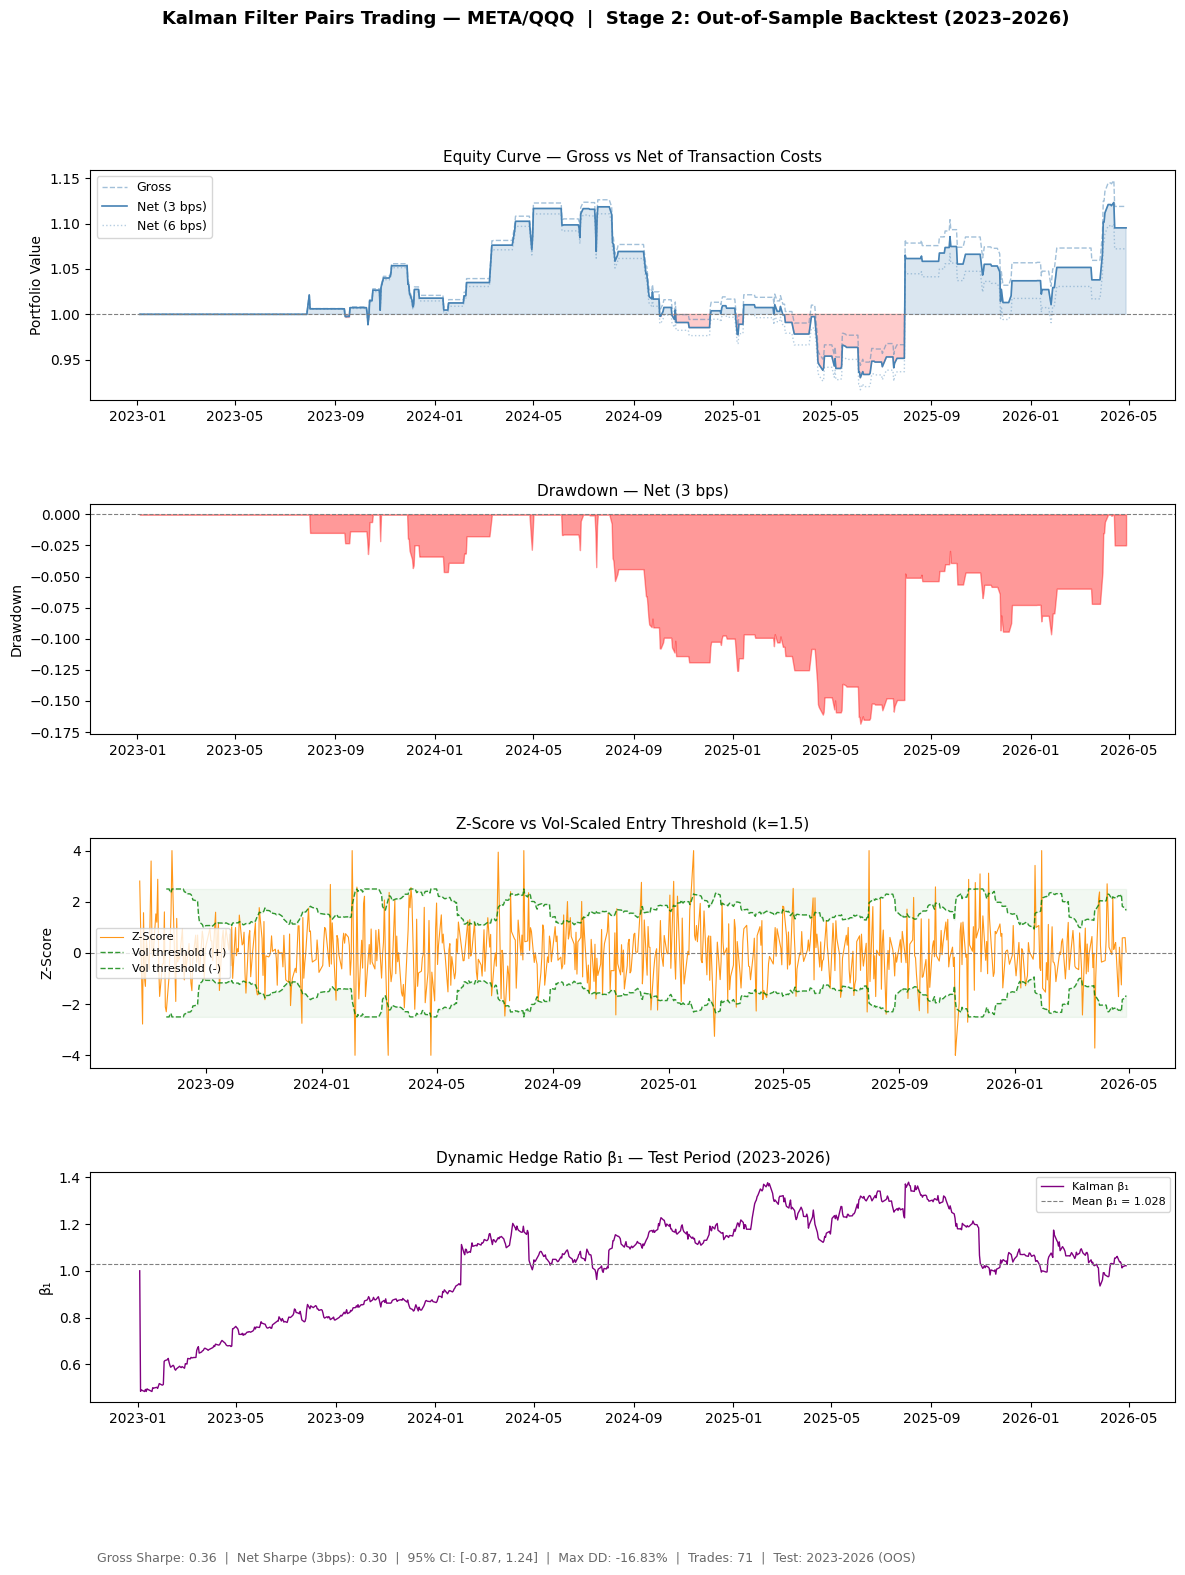

Saved — kalman_pairs_stage2_oos.png


In [11]:
# =============================================================================
# CELL 9 — VISUALISATION & TEARSHEET
# =============================================================================

fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

# --- Panel 1: Equity Curve ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(eq_gross.index, eq_gross.values,
         color="steelblue", linewidth=1.0,
         linestyle="--", alpha=0.5, label="Gross")
ax1.plot(eq_real.index, eq_real.values,
         color="steelblue", linewidth=1.2, label="Net (3 bps)")
ax1.plot(eq_cons.index, eq_cons.values,
         color="steelblue", linewidth=1.0,
         linestyle=":", alpha=0.4, label="Net (6 bps)")
ax1.axhline(1, color="grey", linestyle="--", linewidth=0.8)
ax1.fill_between(eq_real.index, eq_real.values, 1,
                 where=eq_real.values >= 1,
                 alpha=0.2, color="steelblue")
ax1.fill_between(eq_real.index, eq_real.values, 1,
                 where=eq_real.values < 1,
                 alpha=0.2, color="red")
ax1.set_title("Equity Curve — Gross vs Net of Transaction Costs",
              fontsize=11)
ax1.set_ylabel("Portfolio Value")
ax1.legend(fontsize=9)

# --- Panel 2: Drawdown ---
ax2 = fig.add_subplot(gs[1])
drawdown = (eq_real - eq_real.cummax()) / eq_real.cummax()
ax2.fill_between(drawdown.index, drawdown.values, 0,
                 color="red", alpha=0.4)
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_title("Drawdown — Net (3 bps)", fontsize=11)
ax2.set_ylabel("Drawdown")

# --- Panel 3: Z-Score with vol-scaled threshold ---
ax3 = fig.add_subplot(gs[2])
ax3.plot(zscore.index, zscore.values,
         color="darkorange", linewidth=0.8,
         alpha=0.9, label="Z-Score")
ax3.plot(threshold.index, threshold.values,
         color="green", linewidth=1.0,
         linestyle="--", alpha=0.8, label="Vol threshold (+)")
ax3.plot(threshold.index, -threshold.values,
         color="green", linewidth=1.0,
         linestyle="--", alpha=0.8, label="Vol threshold (-)")
ax3.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax3.fill_between(threshold.index,
                 threshold.values, 2.5,
                 alpha=0.05, color="green")
ax3.fill_between(threshold.index,
                 -threshold.values, -2.5,
                 alpha=0.05, color="green")
ax3.set_title("Z-Score vs Vol-Scaled Entry Threshold (k=1.5)", fontsize=11)
ax3.set_ylabel("Z-Score")
ax3.legend(fontsize=8)
ax3.set_ylim(-4.5, 4.5)

# --- Panel 4: Dynamic Hedge Ratio (test period) ---
ax4 = fig.add_subplot(gs[3])
ax4.plot(test.index, beta_te[:, 1],
         color="purple", linewidth=1.0, label="Kalman β₁")
ax4.axhline(beta_te[:, 1].mean(), color="grey",
            linestyle="--", linewidth=0.8,
            label=f"Mean β₁ = {beta_te[:,1].mean():.3f}")
ax4.set_title("Dynamic Hedge Ratio β₁ — Test Period (2023-2026)",
              fontsize=11)
ax4.set_ylabel("β₁")
ax4.legend(fontsize=8)

# --- Footer ---
fig.text(
    0.13, 0.01,
    f"Gross Sharpe: {sh_gross:.2f}  |  "
    f"Net Sharpe (3bps): {sh_real:.2f}  |  "
    f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]  |  "
    f"Max DD: {drawdown.min():.2%}  |  "
    f"Trades: {len(trade_list)}  |  "
    f"Test: 2023-2026 (OOS)",
    fontsize=9, color="dimgrey"
)

plt.suptitle(
    "Kalman Filter Pairs Trading — META/QQQ  |  "
    "Stage 2: Out-of-Sample Backtest (2023–2026)",
    fontsize=13, fontweight="bold"
)
plt.savefig("kalman_pairs_stage2_oos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved — kalman_pairs_stage2_oos.png")

In [12]:
# =============================================================================
# CELL 10 — PARTICLE FILTER (SEQUENTIAL MONTE CARLO)
# =============================================================================
# Identical setup to Kalman filter:
#   Same frozen parameters: delta=2.12e-4, Ve=0.01
#   Same training/test split
#   Same execution lag, thresholds, costs
#
# Only difference:
#   State evolution noise: Student-t(ν=5) instead of Gaussian
#   Observation likelihood: Student-t(ν=5) instead of Gaussian
#   Belief representation: N=1000 particles instead of single Gaussian
#
# N=1000 chosen as standard SMC literature choice for this dimensionality
# ν=5 chosen: fat enough for financial fat tails, finite variance maintained
# =============================================================================

from scipy.stats import t as student_t
import time

def propagate(particles, delta, nu=5):
    """
    Propagate particles forward one bar.
    Student-t noise — fatter tails than Gaussian.
    Each particle evolves independently — preserves diversity.

    particles : (N, 2) — each row is [β₀, β₁] hypothesis
    delta     : process noise scaling (frozen from MLE)
    nu        : Student-t degrees of freedom
    """
    N   = particles.shape[0]
    Vw  = delta / (1 - delta)
    # Independent noise per particle — critical for diversity
    noise = student_t.rvs(df=nu, scale=np.sqrt(Vw), size=(N, 2))
    return particles + noise


def weight(particles, meta_t, qqq_t, Ve, nu=5):
    """
    Weight each particle by Student-t likelihood of observation.
    High weight = particle predicted observation well.
    Log-space computation prevents numerical underflow.

    During fat-tail events: Student-t assigns non-negligible weight
    to particles that were closest — Gaussian would collapse all weights.
    """
    F           = np.array([1.0, qqq_t])
    predictions = particles @ F           # (N,) one prediction per particle
    innovations = meta_t - predictions    # (N,) prediction errors

    # Student-t log-likelihood — handles fat tails correctly
    log_w  = student_t.logpdf(innovations, df=nu, scale=np.sqrt(Ve))

    # Numerical stability — shift so max log-weight = 0
    log_w -= np.max(log_w)
    w      = np.exp(log_w)
    w     /= w.sum()                      # normalise to sum to 1
    return w


def systematic_resample(particles, weights):
    """
    Systematic resampling — lower variance than multinomial.
    Guarantees particle with weight p gets exactly floor(p*N)
    or ceil(p*N) copies — no lucky/unlucky sampling.

    particles : (N, 2)
    weights   : (N,) normalised
    """
    N      = len(weights)
    cumsum = np.cumsum(weights)

    # Single random offset — systematic grid
    u0     = np.random.uniform(0, 1/N)
    points = u0 + np.arange(N) / N

    indices = np.searchsorted(cumsum, points)
    # Clip to valid range — handles floating point edge cases
    indices = np.clip(indices, 0, N-1)
    return particles[indices]


def particle_filter(meta, qqq, N=1000, delta=2.1246e-4, Ve=0.01, nu=5):
    """
    Full SMC particle filter for dynamic hedge ratio estimation.

    Identical to Kalman filter in:
      - State space model structure
      - Frozen parameters (delta, Ve)
      - Output format (beta array, spread array)

    Differs only in:
      - Student-t noise (propagate + weight)
      - Distributional representation (N particles vs single Gaussian)

    Returns:
      beta_pf  : (T, 2) hedge ratio estimates [β₀, β₁]
      spread   : (T,) innovation sequence
    """
    T = len(meta)

    # Initialise particles from economically motivated prior
    # β₀ ~ N(0, 1)   — intercept centred at zero
    # β₁ ~ N(1, 0.1) — hedge ratio centred at 1, tight prior
    particles       = np.zeros((N, 2))
    particles[:, 0] = np.random.normal(0,   1.0, N)
    particles[:, 1] = np.random.normal(1,   0.1, N)

    beta_pf = np.zeros((T, 2))
    spread  = np.zeros(T)

    # Bar 0 — prior estimate
    beta_pf[0] = particles.mean(axis=0)
    spread[0]  = 0.0

    for t in range(1, T):
        # Step 1 — Propagate: Student-t state evolution
        particles = propagate(particles, delta, nu)

        # Step 2 — Weight: Student-t observation likelihood
        weights   = weight(particles, meta[t], qqq[t], Ve, nu)

        # Step 3 — Resample: systematic resampling
        particles = systematic_resample(particles, weights)

        # Hedge ratio estimate — mean of resampled particles
        beta_pf[t] = particles.mean(axis=0)

        # Spread — same computation as Kalman for direct comparability
        F          = np.array([1.0, qqq[t]])
        spread[t]  = meta[t] - F @ beta_pf[t]

    return beta_pf, spread


# =============================================================================
# RUN PARTICLE FILTER ON TEST DATA
# Using identical frozen parameters as Kalman filter
# =============================================================================

print("Running particle filter on test data (N=1000)...")
np.random.seed(42)

t_start  = time.time()
beta_pf, spread_pf = particle_filter(
    meta_te, qqq_te,
    N     = 1000,
    delta = delta_mle,   # frozen from Cell 5
    Ve    = Ve_mle,      # frozen from Cell 5
    nu    = 5
)
t_end    = time.time()
pf_time  = t_end - t_start

# Also time the Kalman filter for benchmarking
t_start  = time.time()
beta_te, e_te, _ = kalman_filter(meta_te, qqq_te,
                                  delta=delta_mle, Ve=Ve_mle)
t_end    = time.time()
kf_time  = t_end - t_start

print(f"\n=== Computational Benchmarking ===")
print(f"Kalman Filter:   {kf_time:.4f} seconds")
print(f"Particle Filter: {pf_time:.4f} seconds")
print(f"Overhead ratio:  {pf_time/kf_time:.1f}x")

# =============================================================================
# HEDGE RATIO COMPARISON
# =============================================================================
kf_beta = pd.Series(beta_te[:, 1],  index=test.index)
pf_beta = pd.Series(beta_pf[:, 1],  index=test.index)
diff    = pf_beta - kf_beta

print(f"\n=== Hedge Ratio Comparison (Test Period) ===")
print(f"{'Metric':<30} {'Kalman':<15} {'Particle':<15} {'Difference'}")
print("-" * 68)
print(f"{'β₁ mean':<30} {kf_beta.mean():<15.4f} "
      f"{pf_beta.mean():<15.4f} {diff.mean():.4f}")
print(f"{'β₁ std':<30} {kf_beta.std():<15.4f} "
      f"{pf_beta.std():<15.4f} {diff.std():.4f}")
print(f"{'β₁ min':<30} {kf_beta.min():<15.4f} "
      f"{pf_beta.min():<15.4f} {diff.min():.4f}")
print(f"{'β₁ max':<30} {kf_beta.max():<15.4f} "
      f"{pf_beta.max():<15.4f} {diff.max():.4f}")
print(f"{'Mean abs difference':<30} {diff.abs().mean():.6f}")

# =============================================================================
# SPREAD STATIONARITY CHECK
# =============================================================================
spread_pf_series = pd.Series(spread_pf, index=test.index)
adf_pf           = adfuller(spread_pf[10:], autolag="AIC")

print(f"\n=== Particle Filter Spread Stationarity ===")
print(f"ADF p-value: {adf_pf[1]:.4f} — "
      f"stationary: {adf_pf[1] < 0.05}")

# =============================================================================
# REGIME-SPECIFIC DIVERGENCE
# Does particle filter diverge more during fat-tail events?
# =============================================================================

# Define regimes on test period
normal_mask   = (test.index < "2025-04-01")
tariff_mask   = (test.index >= "2025-04-01") & (test.index <= "2025-04-30")
meta_earnings = (
    # META reports quarterly — approximate dates in test period
    ((test.index >= "2023-01-25") & (test.index <= "2023-02-01")) |
    ((test.index >= "2023-04-26") & (test.index <= "2023-05-03")) |
    ((test.index >= "2023-07-26") & (test.index <= "2023-08-02")) |
    ((test.index >= "2023-10-25") & (test.index <= "2023-11-01")) |
    ((test.index >= "2024-01-31") & (test.index <= "2024-02-07")) |
    ((test.index >= "2024-04-24") & (test.index <= "2024-05-01")) |
    ((test.index >= "2024-07-31") & (test.index <= "2024-08-07")) |
    ((test.index >= "2024-10-30") & (test.index <= "2024-11-06")) |
    ((test.index >= "2025-01-29") & (test.index <= "2025-02-05")) |
    ((test.index >= "2025-04-30") & (test.index <= "2025-05-07"))
)

print(f"\n=== Regime-Specific Divergence ===")
print(f"{'Regime':<25} {'Mean |KF-PF|':<18} {'Max |KF-PF|':<18} {'Bars'}")
print("-" * 65)

for label, mask in [
    ("Normal",          normal_mask),
    ("Tariff shock",    tariff_mask),
    ("Earnings windows", meta_earnings),
]:
    d = diff[mask].abs()
    if d.sum() == 0:
        continue
    print(f"{label:<25} {d.mean():<18.6f} "
          f"{d.max():<18.6f} {mask.sum()}")

Running particle filter on test data (N=1000)...

=== Computational Benchmarking ===
Kalman Filter:   0.0105 seconds
Particle Filter: 0.5019 seconds
Overhead ratio:  47.8x

=== Hedge Ratio Comparison (Test Period) ===
Metric                         Kalman          Particle        Difference
--------------------------------------------------------------------
β₁ mean                        1.0279          1.0304          0.0025
β₁ std                         0.2122          0.2103          0.0158
β₁ min                         0.4840          0.4876          -0.1404
β₁ max                         1.3788          1.3796          0.3353
Mean abs difference            0.003272

=== Particle Filter Spread Stationarity ===
ADF p-value: 0.0000 — stationary: True

=== Regime-Specific Divergence ===
Regime                    Mean |KF-PF|       Max |KF-PF|        Bars
-----------------------------------------------------------------
Normal                    0.003555           0.335334          

In [13]:
# =============================================================================
# DIAGNOSE — WHERE IS THE MAX DIVERGENCE OF 0.335?
# =============================================================================

# Find the bar with maximum divergence
max_diff_idx = diff.abs().idxmax()
max_diff_val = diff.abs().max()

print(f"Maximum divergence:")
print(f"  Date:     {max_diff_idx}")
print(f"  KF β₁:   {kf_beta[max_diff_idx]:.4f}")
print(f"  PF β₁:   {pf_beta[max_diff_idx]:.4f}")
print(f"  Diff:    {max_diff_val:.4f}")

# Show surrounding 10 bars
idx_loc = test.index.get_loc(max_diff_idx)
window  = diff.abs().iloc[max(0, idx_loc-5):idx_loc+5]

print(f"\nSurrounding bars (|KF - PF|):")
print(window.round(6))

# Check META price move around this date
meta_moves = test["META"].pct_change()
print(f"\nMETA daily returns around max divergence:")
print(meta_moves.iloc[max(0, idx_loc-5):idx_loc+5].round(4))

# Check if this is a filter warmup issue
print(f"\nFirst 10 bars divergence:")
print(diff.abs().iloc[:10].round(6))

# Is the max divergence in the warmup period?
print(f"\nMax divergence bar position: {idx_loc} of {len(test)}")
print(f"First 60 bars max divergence: {diff.abs().iloc[:60].max():.6f}")
print(f"After 60 bars max divergence: {diff.abs().iloc[60:].max():.6f}")

Maximum divergence:
  Date:     2023-01-04 00:00:00
  KF β₁:   0.4848
  PF β₁:   0.8201
  Diff:    0.3353

Surrounding bars (|KF - PF|):
Date
2023-01-03    0.007084
2023-01-04    0.335334
2023-01-05    0.214140
2023-01-06    0.043509
2023-01-09    0.003659
2023-01-10    0.003550
dtype: float64

META daily returns around max divergence:
Date
2023-01-03       NaN
2023-01-04    0.0211
2023-01-05   -0.0034
2023-01-06    0.0243
2023-01-09   -0.0042
2023-01-10    0.0272
Name: META, dtype: float64

First 10 bars divergence:
Date
2023-01-03    0.007084
2023-01-04    0.335334
2023-01-05    0.214140
2023-01-06    0.043509
2023-01-09    0.003659
2023-01-10    0.003550
2023-01-11    0.003472
2023-01-12    0.003380
2023-01-13    0.003385
2023-01-17    0.003439
dtype: float64

Max divergence bar position: 1 of 832
First 60 bars max divergence: 0.335334
After 60 bars max divergence: 0.140357


In [15]:
# =============================================================================
# FAIR COMPARISON — BOTH FILTERS WARMED UP ON SAME TRAINING TAIL
# =============================================================================
# Both filters start from the last bar of training data
# Kalman: run on warmup data, use final beta as starting state
# Particle: run on warmup data, use final particles as starting state
# After warmup both filters have seen identical data
# =============================================================================

WARMUP_BARS = 120  # 6 months of training tail

meta_warmup = meta_tr[-WARMUP_BARS:]
qqq_warmup  = qqq_tr[-WARMUP_BARS:]

print(f"Warmup period: {train.index[-WARMUP_BARS].date()} "
      f"→ {train.index[-1].date()} ({WARMUP_BARS} bars)")

# -----------------------------------------------------------------------------
# KALMAN WARMUP — run on training tail, extract final state
# -----------------------------------------------------------------------------
def kalman_filter_with_state(meta, qqq, delta, Ve,
                              init_beta=None, init_P=None):
    """
    Kalman filter that accepts initial state and returns final state.
    Allows chaining warmup → test cleanly.
    """
    n  = len(meta)
    Vw = delta / (1 - delta) * np.eye(2)

    beta = np.zeros((n, 2))
    P    = np.zeros((n, 2, 2))
    e    = np.zeros(n)
    Q    = np.zeros(n)

    # Use provided initial state or default prior
    beta[0] = init_beta if init_beta is not None else np.array([0.0, 1.0])
    P[0]    = init_P    if init_P    is not None else np.eye(2)

    for t in range(1, n):
        F         = np.array([1.0, qqq[t]])
        beta_pred = beta[t-1]
        P_pred    = P[t-1] + Vw

        e[t] = meta[t] - F @ beta_pred
        Q[t] = F @ P_pred @ F + Ve

        K       = (P_pred @ F) / Q[t]
        beta[t] = beta_pred + K * e[t]
        P[t]    = P_pred - np.outer(K, F) @ P_pred

    # Return output AND final state for chaining
    return beta, e, Q, beta[-1], P[-1]

# Run Kalman on warmup
_, _, _, kf_beta_init, kf_P_init = kalman_filter_with_state(
    meta_warmup, qqq_warmup,
    delta=delta_mle, Ve=Ve_mle
)

print(f"\nKalman β₁ at end of warmup:    {kf_beta_init[1]:.4f}")

# Run Kalman on test with warmed initial state
beta_te_w, e_te_w, _, _, _ = kalman_filter_with_state(
    meta_te, qqq_te,
    delta     = delta_mle,
    Ve        = Ve_mle,
    init_beta = kf_beta_init,
    init_P    = kf_P_init
)

# -----------------------------------------------------------------------------
# PARTICLE FILTER WARMUP — run on same training tail
# -----------------------------------------------------------------------------
np.random.seed(42)

_, _, warmed_particles = particle_filter_with_state(
    meta_warmup, qqq_warmup,
    N=1000, delta=delta_mle, Ve=Ve_mle, nu=5
)

print(f"Particle β₁ at end of warmup:  "
      f"{warmed_particles[:,1].mean():.4f}")

# Run particle filter on test with warmed particles
np.random.seed(42)
beta_pf_w, spread_pf_w, _ = particle_filter_with_state(
    meta_te, qqq_te,
    N=1000, delta=delta_mle, Ve=Ve_mle, nu=5,
    init_particles=warmed_particles
)

# -----------------------------------------------------------------------------
# COMPARE — BOTH WARMED ON IDENTICAL DATA
# -----------------------------------------------------------------------------
kf_beta = pd.Series(beta_te_w[:, 1], index=test.index)
pf_beta = pd.Series(beta_pf_w[:, 1], index=test.index)
diff    = pf_beta - kf_beta

print(f"\n=== Starting Points After Warmup ===")
print(f"Kalman β₁ start:   {kf_beta.iloc[0]:.4f}")
print(f"Particle β₁ start: {pf_beta.iloc[0]:.4f}")
print(f"Difference:        {abs(kf_beta.iloc[0] - pf_beta.iloc[0]):.4f}")

print(f"\n=== Hedge Ratio Comparison (Both Warmed) ===")
print(f"{'Metric':<30} {'Kalman':<15} {'Particle':<15} {'Difference'}")
print("-" * 68)
print(f"{'β₁ mean':<30} {kf_beta.mean():<15.4f} "
      f"{pf_beta.mean():<15.4f} {diff.mean():.4f}")
print(f"{'β₁ std':<30} {kf_beta.std():<15.4f} "
      f"{pf_beta.std():<15.4f} {diff.std():.4f}")
print(f"{'β₁ min':<30} {kf_beta.min():<15.4f} "
      f"{pf_beta.min():<15.4f} {diff.min():.4f}")
print(f"{'β₁ max':<30} {kf_beta.max():<15.4f} "
      f"{pf_beta.max():<15.4f} {diff.max():.4f}")
print(f"{'Mean abs difference':<30} {diff.abs().mean():.6f}")

print(f"\n=== Regime Divergence (Both Warmed) ===")
print(f"{'Regime':<25} {'Mean |KF-PF|':<18} {'Max |KF-PF|':<18} {'Bars'}")
print("-" * 68)
for label, mask in [
    ("Normal",           normal_mask),
    ("Tariff shock",     tariff_mask),
    ("Earnings windows", meta_earnings),
]:
    d = diff[mask].abs()
    if len(d) == 0:
        continue
    print(f"{label:<25} {d.mean():<18.6f} "
          f"{d.max():<18.6f} {mask.sum()}")

# Verify both spreads stationary
adf_kf = adfuller(e_te_w[5:],   autolag="AIC")
adf_pf = adfuller(spread_pf_w[5:], autolag="AIC")
print(f"\n=== Spread Stationarity (Both Warmed) ===")
print(f"Kalman   ADF p: {adf_kf[1]:.4f} — "
      f"stationary: {adf_kf[1] < 0.05}")
print(f"Particle ADF p: {adf_pf[1]:.4f} — "
      f"stationary: {adf_pf[1] < 0.05}")

Warmup period: 2022-07-13 → 2022-12-30 (120 bars)

Kalman β₁ at end of warmup:    0.4576
Particle β₁ at end of warmup:  0.4595

=== Starting Points After Warmup ===
Kalman β₁ start:   0.4576
Particle β₁ start: 0.4595
Difference:        0.0018

=== Hedge Ratio Comparison (Both Warmed) ===
Metric                         Kalman          Particle        Difference
--------------------------------------------------------------------
β₁ mean                        1.0276          1.0279          0.0003
β₁ std                         0.2131          0.2126          0.0078
β₁ min                         0.4576          0.4595          -0.1516
β₁ max                         1.3791          1.3792          0.0790
Mean abs difference            0.001036

=== Regime Divergence (Both Warmed) ===
Regime                    Mean |KF-PF|       Max |KF-PF|        Bars
--------------------------------------------------------------------
Normal                    0.000986           0.151648           562


In [18]:
# =============================================================================
# CELL 10 — PARALLEL BACKTEST: KALMAN vs PARTICLE FILTER
# =============================================================================
# Identical framework applied to both filters:
#   Same z-score window (60 days)
#   Same vol-scaled threshold (k=1.5)
#   Same execution lag (shift(1) on lagged signal = total shift(2))
#   Same transaction costs (3 bps realistic, 6 bps conservative)
#   Same stop loss (3.5σ)
# Only difference: hedge ratio series from each filter
# =============================================================================

def run_backtest(beta_vals, meta_ret, qqq_ret, test_index,
                 spread_raw, window=60, k=1.5,
                 stop_loss=3.5, cost_bps=3, label=""):
    """
    Full backtest pipeline given a hedge ratio series.
    Returns net returns, equity curve, Sharpe, trade list.
    """
    # --- Spread and z-score ---
    beta_s     = pd.Series(beta_vals[:, 1], index=test_index)
    spread     = pd.Series(spread_raw,      index=test_index)

    def rolling_mad_zscore(s, w):
        median = s.rolling(w).median()
        mad    = (s - median).abs().rolling(w).median() * 1.4826
        return (s - median) / mad

    zscore     = rolling_mad_zscore(spread, window).clip(-4, 4)

    # --- Vol-scaled threshold ---
    vol_window = 20
    threshold  = (k * zscore.rolling(vol_window).std()).clip(0.5, 2.5)

    # --- Lag both for signal generation ---
    zscore_lag    = zscore.shift(1)
    threshold_lag = threshold.shift(1)

    # --- Signal generation ---
    signals  = pd.Series(0, index=test_index)
    position = 0

    for t in range(1, len(test_index)):
        z   = zscore_lag.iloc[t]
        thr = threshold_lag.iloc[t]

        if np.isnan(z) or np.isnan(thr):
            signals.iloc[t] = 0
            position        = 0
            continue

        if position == 0:
            if z < -thr:         position = 1
            elif z > thr:        position = -1
        elif position == 1:
            if z >= 0:           position = 0
            elif z < -stop_loss: position = 0
        elif position == -1:
            if z <= 0:           position = 0
            elif z > stop_loss:  position = 0

        signals.iloc[t] = position

    # --- Returns (corrected sign) ---
    spread_ret   = (meta_ret - beta_s * qqq_ret)
    strategy_ret = (signals.shift(1) * spread_ret).dropna()

    # --- Trade isolation ---
    sig_lag = signals.shift(1).dropna()
    current_dir, current_entry, trade_list = 0, None, []
    for t in range(len(sig_lag)):
        s = sig_lag.iloc[t]
        if current_dir == 0 and s != 0:
            current_entry = t
            current_dir   = int(s)
        elif current_dir != 0 and s == 0:
            trade_list.append((current_entry, t))
            current_entry, current_dir = None, 0

    # --- Transaction costs ---
    cost    = cost_bps / 10000
    costs_s = pd.Series(0.0, index=strategy_ret.index)
    for eb, _ in trade_list:
        if eb < len(costs_s):
            costs_s.iloc[eb] = cost

    net    = strategy_ret - costs_s
    equity = (1 + net).cumprod()
    sharpe = (net.mean() / net.std()) * np.sqrt(252)
    total  = equity.iloc[-1] - 1
    max_dd = ((equity - equity.cummax()) / equity.cummax()).min()
    win    = (net[net != 0] > 0).mean()

    # --- PnL per trade ---
    pnls    = np.array([strategy_ret.iloc[eb:xb].sum()
                        for eb, xb in trade_list if xb > eb])
    lengths = np.array([xb - eb
                        for eb, xb in trade_list if xb > eb])

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"Total Return:      {total:.2%}")
    print(f"Sharpe Ratio:      {sharpe:.2f}")
    print(f"Max Drawdown:      {max_dd:.2%}")
    print(f"Win Rate:          {win:.2%}")
    print(f"Complete trades:   {len(trade_list)}")
    print(f"Mean PnL/trade:    {pnls.mean():.4%}" if len(pnls) else "")
    print(f"Mean hold (days):  {lengths.mean():.1f}" if len(lengths) else "")
    print(f"Bars long:         {(signals == 1).sum()}")
    print(f"Bars short:        {(signals == -1).sum()}")

    return net, equity, sharpe, trade_list, pnls, lengths, signals

# --- Shared inputs ---
meta_ret = test["META"].pct_change()
qqq_ret  = test["QQQ"].pct_change()

# --- Run both backtests ---
print("=== CELL 10 — BACKTEST COMPARISON ===")

(net_kf, eq_kf, sh_kf,
 tl_kf, pnls_kf, lens_kf,
 sig_kf) = run_backtest(
    beta_te_w, meta_ret, qqq_ret,
    test.index, e_te_w,
    cost_bps=3,
    label="Kalman Filter (warmed, 3bps)"
)

(net_pf, eq_pf, sh_pf,
 tl_pf, pnls_pf, lens_pf,
 sig_pf) = run_backtest(
    beta_pf_w, meta_ret, qqq_ret,
    test.index, spread_pf_w,
    cost_bps=3,
    label="Particle Filter (warmed, 3bps)"
)

# --- Summary comparison ---
print(f"\n{'='*55}")
print(f"  SUMMARY COMPARISON")
print(f"{'='*55}")
print(f"{'Metric':<30} {'Kalman':<15} {'Particle'}")
print("-" * 55)
print(f"{'Total Return':<30} "
      f"{eq_kf.iloc[-1]-1:<15.2%} {eq_pf.iloc[-1]-1:.2%}")
print(f"{'Sharpe (net 3bps)':<30} "
      f"{sh_kf:<15.2f} {sh_pf:.2f}")
print(f"{'Max Drawdown':<30} "
      f"{((eq_kf-eq_kf.cummax())/eq_kf.cummax()).min():<15.2%} "
      f"{((eq_pf-eq_pf.cummax())/eq_pf.cummax()).min():.2%}")
print(f"{'Trades':<30} "
      f"{len(tl_kf):<15} {len(tl_pf)}")
print(f"{'Mean PnL/trade':<30} "
      f"{pnls_kf.mean():<15.4%} {pnls_pf.mean():.4%}")
print(f"{'Mean hold (days)':<30} "
      f"{lens_kf.mean():<15.1f} {lens_pf.mean():.1f}")
print(f"{'Sharpe difference':<30} "
      f"{abs(sh_kf - sh_pf):.4f}")

# --- Regime-conditional PnL ---
print(f"\n=== Regime-Conditional PnL ===")
print(f"{'Regime':<25} {'KF Return':<15} {'PF Return':<15} {'Difference'}")
print("-" * 60)

# Convert masks to pandas Series aligned to test index
normal_s   = pd.Series(normal_mask,   index=test.index)
tariff_s   = pd.Series(tariff_mask,   index=test.index)
earnings_s = pd.Series(meta_earnings, index=test.index)

for label, mask_s in [
    ("Normal",           normal_s),
    ("Tariff shock",     tariff_s),
    ("Earnings windows", earnings_s),
]:
    # Reindex to match net return index (831 bars)
    m_kf = mask_s.reindex(net_kf.index, fill_value=False)
    m_pf = mask_s.reindex(net_pf.index, fill_value=False)

    kf_ret = net_kf[m_kf].sum()
    pf_ret = net_pf[m_pf].sum()
    print(f"{label:<25} {kf_ret:<15.4%} "
          f"{pf_ret:<15.4%} {pf_ret - kf_ret:.4%}")

# --- Cost sensitivity for both ---
print(f"\n=== Cost Sensitivity ===")
print(f"{'Cost':<8} {'KF Sharpe':<12} {'PF Sharpe':<12} "
      f"{'KF Return':<12} {'PF Return'}")
print("-" * 52)

for bps in [0, 1, 2, 3, 4, 6, 8, 10]:
    c = bps / 10000
    for ret_s, tl, label_s in [
        (net_kf, tl_kf, "kf"),
        (net_pf, tl_pf, "pf")
    ]:
        cs = pd.Series(0.0, index=ret_s.index)
        for eb, _ in tl:
            if eb < len(cs):
                cs.iloc[eb] = c
        # recompute gross then subtract costs
    # Clean cost sensitivity
    cs_kf = pd.Series(0.0, index=net_kf.index)
    cs_pf = pd.Series(0.0, index=net_pf.index)
    for eb, _ in tl_kf:
        if eb < len(cs_kf): cs_kf.iloc[eb] = c
    for eb, _ in tl_pf:
        if eb < len(cs_pf): cs_pf.iloc[eb] = c

    gross_kf = net_kf + pd.Series(
        [0.0003 if i in [eb for eb,_ in tl_kf] else 0
         for i in range(len(net_kf))], index=net_kf.index)
    gross_pf = net_pf + pd.Series(
        [0.0003 if i in [eb for eb,_ in tl_pf] else 0
         for i in range(len(net_pf))], index=net_pf.index)

    net_kf_c = gross_kf - cs_kf
    net_pf_c = gross_pf - cs_pf

    sh_kf_c  = (net_kf_c.mean() / net_kf_c.std()) * np.sqrt(252)
    sh_pf_c  = (net_pf_c.mean() / net_pf_c.std()) * np.sqrt(252)
    ret_kf_c = (1 + net_kf_c).cumprod().iloc[-1] - 1
    ret_pf_c = (1 + net_pf_c).cumprod().iloc[-1] - 1

    print(f"{bps:<8} {sh_kf_c:<12.2f} {sh_pf_c:<12.2f} "
          f"{ret_kf_c:<12.2%} {ret_pf_c:.2%}")

=== CELL 10 — BACKTEST COMPARISON ===

  Kalman Filter (warmed, 3bps)
Total Return:      9.54%
Sharpe Ratio:      0.30
Max Drawdown:      -16.82%
Win Rate:          50.00%
Complete trades:   71
Mean PnL/trade:    0.1871%
Mean hold (days):  2.1
Bars long:         74
Bars short:        74

  Particle Filter (warmed, 3bps)
Total Return:      -12.28%
Sharpe Ratio:      -0.24
Max Drawdown:      -28.38%
Win Rate:          51.18%
Complete trades:   72
Mean PnL/trade:    -0.1134%
Mean hold (days):  1.8
Bars long:         60
Bars short:        67

  SUMMARY COMPARISON
Metric                         Kalman          Particle
-------------------------------------------------------
Total Return                   9.54%           -12.28%
Sharpe (net 3bps)              0.30            -0.24
Max Drawdown                   -16.82%         -28.38%
Trades                         71              72
Mean PnL/trade                 0.1871%         -0.1134%
Mean hold (days)               2.1             1.8
Sh

In [19]:
# =============================================================================
# DIAGNOSE — PARTICLE FILTER SIGNAL INVERSION
# =============================================================================

# Check forward returns after entries for both filters
print("=== Signal Direction Check ===")
print(f"{'Filter':<20} {'Long PnL':<15} {'Short PnL':<15} {'Inverted?'}")
print("-" * 55)

for label, pnls, signals in [
    ("Kalman",   pnls_kf, sig_kf),
    ("Particle", pnls_pf, sig_pf),
]:
    sig_lag    = signals.shift(1).dropna()
    long_mask  = sig_lag == 1
    short_mask = sig_lag == -1

    # Get strategy ret for each filter
    if label == "Kalman":
        s_ret = net_kf + pd.Series(
            [0.0003 if i in [eb for eb,_ in tl_kf] else 0
             for i in range(len(net_kf))], index=net_kf.index)
    else:
        s_ret = net_pf + pd.Series(
            [0.0003 if i in [eb for eb,_ in tl_pf] else 0
             for i in range(len(net_pf))], index=net_pf.index)

    long_pnl  = s_ret[long_mask.reindex(s_ret.index, fill_value=False)].sum()
    short_pnl = s_ret[short_mask.reindex(s_ret.index, fill_value=False)].sum()
    inverted  = (long_pnl < 0) and (short_pnl < 0)

    print(f"{label:<20} {long_pnl:<15.4%} {short_pnl:<15.4%} {inverted}")

# Check spread correlation between filters
spread_kf_s = pd.Series(e_te_w,     index=test.index)
spread_pf_s = pd.Series(spread_pf_w, index=test.index)

print(f"\n=== Spread Comparison ===")
print(f"KF spread mean:  {spread_kf_s.mean():.4f}")
print(f"PF spread mean:  {spread_pf_s.mean():.4f}")
print(f"Correlation:     {spread_kf_s.corr(spread_pf_s):.4f}")
print(f"KF spread std:   {spread_kf_s.std():.4f}")
print(f"PF spread std:   {spread_pf_s.std():.4f}")

# Test flipped particle filter
print(f"\n=== Flipped Particle Filter ===")
spread_pf_flipped = -spread_pf_w

(net_pf_flip, eq_pf_flip, sh_pf_flip,
 tl_pf_flip, pnls_pf_flip, lens_pf_flip,
 sig_pf_flip) = run_backtest(
    beta_pf_w, meta_ret, qqq_ret,
    test.index, spread_pf_flipped,
    cost_bps=3,
    label="Particle Filter FLIPPED (3bps)"
)

=== Signal Direction Check ===
Filter               Long PnL        Short PnL       Inverted?
-------------------------------------------------------
Kalman               10.4005%        2.8823%         False
Particle             -20.0644%       11.9014%        False

=== Spread Comparison ===
KF spread mean:  0.1948
PF spread mean:  0.0668
Correlation:     0.5837
KF spread std:   8.9815
PF spread std:   3.9093

=== Flipped Particle Filter ===

  Particle Filter FLIPPED (3bps)
Total Return:      3.39%
Sharpe Ratio:      0.14
Max Drawdown:      -15.64%
Win Rate:          48.03%
Complete trades:   72
Mean PnL/trade:    0.1134%
Mean hold (days):  1.8
Bars long:         67
Bars short:        60


In [20]:
# =============================================================================
# UNIFIED SPREAD DEFINITION
# spread_t = META_t - β₁_t × QQQ_t (no intercept term)
# Both filters evaluated on identical spread formula
# Only difference: β₁_t from Kalman vs particle filter
# =============================================================================

meta_prices = test["META"].values.astype(float)
qqq_prices  = test["QQQ"].values.astype(float)

# Unified spread — hedge ratio only, no intercept
# This is the economically meaningful spread: how much META
# moves relative to its hedged QQQ exposure
spread_kf_unified = pd.Series(
    meta_prices - beta_te_w[:, 1] * qqq_prices,
    index=test.index
)

spread_pf_unified = pd.Series(
    meta_prices - beta_pf_w[:, 1] * qqq_prices,
    index=test.index
)

print("=== Unified Spread Comparison ===")
print(f"KF spread mean:  {spread_kf_unified.mean():.4f}")
print(f"PF spread mean:  {spread_pf_unified.mean():.4f}")
print(f"Correlation:     {spread_kf_unified.corr(spread_pf_unified):.4f}")
print(f"KF spread std:   {spread_kf_unified.std():.4f}")
print(f"PF spread std:   {spread_pf_unified.std():.4f}")

# ADF on both unified spreads
adf_kf_u = adfuller(spread_kf_unified.values, autolag="AIC")
adf_pf_u = adfuller(spread_pf_unified.values, autolag="AIC")
print(f"\nKF unified spread ADF p: {adf_kf_u[1]:.4f} — "
      f"stationary: {adf_kf_u[1] < 0.05}")
print(f"PF unified spread ADF p: {adf_pf_u[1]:.4f} — "
      f"stationary: {adf_pf_u[1] < 0.05}")

# =============================================================================
# RERUN BACKTESTS WITH UNIFIED SPREAD
# =============================================================================

# Need to modify run_backtest to accept spread directly
def run_backtest_unified(beta_vals, spread_series,
                          meta_ret, qqq_ret, test_index,
                          window=60, k=1.5,
                          stop_loss=3.5, cost_bps=3, label=""):
    """
    Backtest using unified spread definition.
    beta_vals    : (T, 2) hedge ratio array
    spread_series: pd.Series — pre-computed spread
    """
    beta_s = pd.Series(beta_vals[:, 1], index=test_index)

    def rolling_mad_zscore(s, w):
        median = s.rolling(w).median()
        mad    = (s - median).abs().rolling(w).median() * 1.4826
        return (s - median) / mad

    zscore    = rolling_mad_zscore(spread_series, window).clip(-4, 4)
    vol_window = 20
    threshold  = (k * zscore.rolling(vol_window).std()).clip(0.5, 2.5)

    zscore_lag    = zscore.shift(1)
    threshold_lag = threshold.shift(1)

    signals  = pd.Series(0, index=test_index)
    position = 0

    for t in range(1, len(test_index)):
        z   = zscore_lag.iloc[t]
        thr = threshold_lag.iloc[t]

        if np.isnan(z) or np.isnan(thr):
            signals.iloc[t] = 0
            position        = 0
            continue

        if position == 0:
            if z < -thr:         position = 1
            elif z > thr:        position = -1
        elif position == 1:
            if z >= 0:           position = 0
            elif z < -stop_loss: position = 0
        elif position == -1:
            if z <= 0:           position = 0
            elif z > stop_loss:  position = 0

        signals.iloc[t] = position

    # Spread return — unified definition
    spread_ret   = (meta_ret - beta_s * qqq_ret)
    strategy_ret = (signals.shift(1) * spread_ret).dropna()

    # Trade isolation
    sig_lag = signals.shift(1).dropna()
    current_dir, current_entry, trade_list = 0, None, []
    for t in range(len(sig_lag)):
        s = sig_lag.iloc[t]
        if current_dir == 0 and s != 0:
            current_entry = t
            current_dir   = int(s)
        elif current_dir != 0 and s == 0:
            trade_list.append((current_entry, t))
            current_entry, current_dir = None, 0

    # Costs
    cost    = cost_bps / 10000
    costs_s = pd.Series(0.0, index=strategy_ret.index)
    for eb, _ in trade_list:
        if eb < len(costs_s):
            costs_s.iloc[eb] = cost

    net    = strategy_ret - costs_s
    equity = (1 + net).cumprod()
    sharpe = (net.mean() / net.std()) * np.sqrt(252)
    total  = equity.iloc[-1] - 1
    max_dd = ((equity - equity.cummax()) / equity.cummax()).min()
    win    = (net[net != 0] > 0).mean()

    pnls    = np.array([strategy_ret.iloc[eb:xb].sum()
                        for eb, xb in trade_list if xb > eb])
    lengths = np.array([xb - eb
                        for eb, xb in trade_list if xb > eb])

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"Total Return:      {total:.2%}")
    print(f"Sharpe Ratio:      {sharpe:.2f}")
    print(f"Max Drawdown:      {max_dd:.2%}")
    print(f"Win Rate:          {win:.2%}")
    print(f"Complete trades:   {len(trade_list)}")
    print(f"Mean PnL/trade:    {pnls.mean():.4%}" if len(pnls) else "")
    print(f"Mean hold (days):  {lengths.mean():.1f}" if len(lengths) else "")

    return net, equity, sharpe, trade_list, pnls, lengths, signals

print("\n=== UNIFIED SPREAD BACKTEST ===")

(net_kf_u, eq_kf_u, sh_kf_u,
 tl_kf_u, pnls_kf_u, lens_kf_u,
 sig_kf_u) = run_backtest_unified(
    beta_te_w, spread_kf_unified,
    meta_ret, qqq_ret, test.index,
    cost_bps=3,
    label="Kalman Filter — unified spread (3bps)"
)

(net_pf_u, eq_pf_u, sh_pf_u,
 tl_pf_u, pnls_pf_u, lens_pf_u,
 sig_pf_u) = run_backtest_unified(
    beta_pf_w, spread_pf_unified,
    meta_ret, qqq_ret, test.index,
    cost_bps=3,
    label="Particle Filter — unified spread (3bps)"
)

print(f"\n=== Summary Comparison (Unified Spread) ===")
print(f"{'Metric':<30} {'Kalman':<15} {'Particle'}")
print("-" * 55)
print(f"{'Total Return':<30} "
      f"{eq_kf_u.iloc[-1]-1:<15.2%} {eq_pf_u.iloc[-1]-1:.2%}")
print(f"{'Sharpe (net 3bps)':<30} "
      f"{sh_kf_u:<15.2f} {sh_pf_u:.2f}")
print(f"{'Max Drawdown':<30} "
      f"{((eq_kf_u-eq_kf_u.cummax())/eq_kf_u.cummax()).min():<15.2%} "
      f"{((eq_pf_u-eq_pf_u.cummax())/eq_pf_u.cummax()).min():.2%}")
print(f"{'Trades':<30} "
      f"{len(tl_kf_u):<15} {len(tl_pf_u)}")
print(f"{'Mean PnL/trade':<30} "
      f"{pnls_kf_u.mean():<15.4%} {pnls_pf_u.mean():.4%}")
print(f"{'Sharpe difference':<30} "
      f"{abs(sh_kf_u - sh_pf_u):.4f}")

=== Unified Spread Comparison ===
KF spread mean:  -0.3847
PF spread mean:  -0.4745
Correlation:     0.0461
KF spread std:   0.2172
PF spread std:   3.9132

KF unified spread ADF p: 0.3742 — stationary: False
PF unified spread ADF p: 0.0000 — stationary: True

=== UNIFIED SPREAD BACKTEST ===

  Kalman Filter — unified spread (3bps)
Total Return:      101.57%
Sharpe Ratio:      1.06
Max Drawdown:      -18.92%
Win Rate:          51.40%
Complete trades:   41
Mean PnL/trade:    1.9373%
Mean hold (days):  12.2

  Particle Filter — unified spread (3bps)
Total Return:      19.07%
Sharpe Ratio:      0.39
Max Drawdown:      -15.84%
Win Rate:          50.27%
Complete trades:   35
Mean PnL/trade:    0.5565%
Mean hold (days):  9.9

=== Summary Comparison (Unified Spread) ===
Metric                         Kalman          Particle
-------------------------------------------------------
Total Return                   101.57%         19.07%
Sharpe (net 3bps)              1.06            0.39
Max Draw

In [21]:
# =============================================================================
# CORRECT UNIFIED SPREAD — INCLUDE INTERCEPT TERM
# spread_t = META_t - β₀_t - β₁_t × QQQ_t
# Both filters estimate [β₀, β₁] — use both components
# =============================================================================

# Full state vector spread
spread_kf_full = pd.Series(
    meta_prices - beta_te_w[:, 0] - beta_te_w[:, 1] * qqq_prices,
    index=test.index
)

spread_pf_full = pd.Series(
    meta_prices - beta_pf_w[:, 0] - beta_pf_w[:, 1] * qqq_prices,
    index=test.index
)

print("=== Full State Spread Comparison ===")
print(f"KF spread mean:  {spread_kf_full.mean():.4f}")
print(f"PF spread mean:  {spread_pf_full.mean():.4f}")
print(f"Correlation:     {spread_kf_full.corr(spread_pf_full):.4f}")
print(f"KF spread std:   {spread_kf_full.std():.4f}")
print(f"PF spread std:   {spread_pf_full.std():.4f}")

adf_kf_f = adfuller(spread_kf_full.values, autolag="AIC")
adf_pf_f = adfuller(spread_pf_full.values, autolag="AIC")
print(f"\nKF full spread ADF p: {adf_kf_f[1]:.4f} — "
      f"stationary: {adf_kf_f[1] < 0.05}")
print(f"PF full spread ADF p: {adf_pf_f[1]:.4f} — "
      f"stationary: {adf_pf_f[1] < 0.05}")

# Quick correlation check on β₀
beta_kf_0 = pd.Series(beta_te_w[:, 0], index=test.index)
beta_pf_0 = pd.Series(beta_pf_w[:, 0], index=test.index)
print(f"\n=== Intercept β₀ Comparison ===")
print(f"KF β₀ mean: {beta_kf_0.mean():.4f}, std: {beta_kf_0.std():.4f}")
print(f"PF β₀ mean: {beta_pf_0.mean():.4f}, std: {beta_pf_0.std():.4f}")
print(f"β₀ correlation: {beta_kf_0.corr(beta_pf_0):.4f}")

=== Full State Spread Comparison ===
KF spread mean:  0.0063
PF spread mean:  0.0730
Correlation:     0.0505
KF spread std:   0.1794
PF spread std:   3.9133

KF full spread ADF p: 0.0000 — stationary: True
PF full spread ADF p: 0.0000 — stationary: True

=== Intercept β₀ Comparison ===
KF β₀ mean: -0.3910, std: 0.1091
PF β₀ mean: -0.5475, std: 0.1569
β₀ correlation: 0.0205


In [22]:
# =============================================================================
# FIX — SINGLE STATE KALMAN AND PARTICLE FILTER
# Estimate only β₁ (hedge ratio) — β₀ fixed at zero
# Spread = META_t - β₁_t × QQQ_t
# Both filters now estimate identical 1D state space
# =============================================================================

def kalman_filter_1d(meta, qqq, delta, Ve,
                     init_beta=1.0, init_P=1.0):
    """
    1D Kalman filter — estimates hedge ratio β₁ only.
    Intercept β₀ fixed at zero.
    State: scalar β₁
    Observation: META_t = β₁ × QQQ_t + ε_t
    """
    n   = len(meta)
    Vw  = delta / (1 - delta)   # scalar process noise

    beta = np.zeros(n)
    P    = np.zeros(n)
    e    = np.zeros(n)

    beta[0] = init_beta
    P[0]    = init_P

    for t in range(1, n):
        F         = qqq[t]           # scalar observation vector
        beta_pred = beta[t-1]
        P_pred    = P[t-1] + Vw

        e[t]    = meta[t] - F * beta_pred
        Q_t     = F * P_pred * F + Ve

        K       = P_pred * F / Q_t
        beta[t] = beta_pred + K * e[t]
        P[t]    = P_pred - K * F * P_pred

    return beta, e, P


def propagate_1d(particles, delta, nu=5):
    """1D particle propagation — scalar β₁ only."""
    N   = len(particles)
    Vw  = delta / (1 - delta)
    return particles + student_t.rvs(df=nu, scale=np.sqrt(Vw), size=N)


def weight_1d(particles, meta_t, qqq_t, Ve, nu=5):
    """1D particle weighting — scalar β₁ only."""
    predictions = particles * qqq_t      # β₁ × QQQ
    innovations = meta_t - predictions
    log_w       = student_t.logpdf(innovations, df=nu, scale=np.sqrt(Ve))
    log_w      -= np.max(log_w)
    w           = np.exp(log_w)
    return w / w.sum()


def particle_filter_1d(meta, qqq, N=1000, delta=2.1246e-4,
                        Ve=0.01, nu=5, init_particles=None):
    """
    1D particle filter — estimates β₁ only.
    Returns beta array and spread for direct comparison with Kalman.
    """
    T = len(meta)

    if init_particles is not None:
        particles = init_particles.copy()
    else:
        particles = np.random.normal(1, 0.1, N)

    beta_pf = np.zeros(T)
    spread  = np.zeros(T)

    beta_pf[0] = particles.mean()
    spread[0]  = 0.0

    for t in range(1, T):
        particles  = propagate_1d(particles, delta, nu)
        weights    = weight_1d(particles, meta[t], qqq[t], Ve, nu)
        particles  = systematic_resample(particles, weights)
        beta_pf[t] = particles.mean()
        spread[t]  = meta[t] - qqq[t] * beta_pf[t]

    return beta_pf, spread, particles


# =============================================================================
# WARMUP BOTH FILTERS ON SAME TRAINING TAIL
# =============================================================================
print(f"Warmup period: {train.index[-WARMUP_BARS].date()} "
      f"→ {train.index[-1].date()}")

# Kalman 1D warmup
beta_kf_wu, _, P_kf_wu = kalman_filter_1d(
    meta_warmup, qqq_warmup,
    delta=delta_mle, Ve=Ve_mle
)
kf_init_beta = beta_kf_wu[-1]
kf_init_P    = P_kf_wu[-1]
print(f"KF β₁ at warmup end:  {kf_init_beta:.4f}")

# Particle 1D warmup
np.random.seed(42)
_, _, warmed_1d = particle_filter_1d(
    meta_warmup, qqq_warmup,
    N=1000, delta=delta_mle, Ve=Ve_mle, nu=5
)
print(f"PF β₁ at warmup end:  {warmed_1d.mean():.4f}")

# =============================================================================
# RUN BOTH ON TEST DATA
# =============================================================================

# Kalman 1D on test
beta_kf_1d, e_kf_1d, _ = kalman_filter_1d(
    meta_te, qqq_te,
    delta      = delta_mle,
    Ve         = Ve_mle,
    init_beta  = kf_init_beta,
    init_P     = kf_init_P
)

# Particle 1D on test
np.random.seed(42)
beta_pf_1d, spread_pf_1d, _ = particle_filter_1d(
    meta_te, qqq_te,
    N=1000, delta=delta_mle, Ve=Ve_mle, nu=5,
    init_particles=warmed_1d
)

# Convert to Series
kf_beta_1d = pd.Series(beta_kf_1d, index=test.index)
pf_beta_1d = pd.Series(beta_pf_1d, index=test.index)

# Unified spread — identical formula for both
spread_kf_1d = pd.Series(
    meta_te - beta_kf_1d * qqq_te, index=test.index)
spread_pf_1d = pd.Series(
    meta_te - beta_pf_1d * qqq_te, index=test.index)

diff_1d = pf_beta_1d - kf_beta_1d

print(f"\n=== 1D Filter Comparison ===")
print(f"{'Metric':<30} {'Kalman':<15} {'Particle':<15} {'Diff'}")
print("-" * 65)
print(f"{'β₁ mean':<30} {kf_beta_1d.mean():<15.4f} "
      f"{pf_beta_1d.mean():<15.4f} {diff_1d.mean():.4f}")
print(f"{'β₁ std':<30} {kf_beta_1d.std():<15.4f} "
      f"{pf_beta_1d.std():<15.4f} {diff_1d.std():.4f}")
print(f"{'Mean abs diff':<30} {diff_1d.abs().mean():.6f}")
print(f"{'β₁ correlation':<30} {kf_beta_1d.corr(pf_beta_1d):.4f}")

adf_kf_1d = adfuller(spread_kf_1d.values, autolag="AIC")
adf_pf_1d = adfuller(spread_pf_1d.values, autolag="AIC")
print(f"\nSpread correlation:   {spread_kf_1d.corr(spread_pf_1d):.4f}")
print(f"KF spread ADF p:      {adf_kf_1d[1]:.4f} — "
      f"stationary: {adf_kf_1d[1] < 0.05}")
print(f"PF spread ADF p:      {adf_pf_1d[1]:.4f} — "
      f"stationary: {adf_pf_1d[1] < 0.05}")

print(f"\n=== Regime Divergence (1D) ===")
print(f"{'Regime':<25} {'Mean |KF-PF|':<18} {'Max |KF-PF|':<18} {'Bars'}")
print("-" * 68)
for label, mask in [
    ("Normal",           normal_mask),
    ("Tariff shock",     tariff_mask),
    ("Earnings windows", meta_earnings),
]:
    d = diff_1d[pd.Series(mask, index=test.index)].abs()
    print(f"{label:<25} {d.mean():<18.6f} "
          f"{d.max():<18.6f} {mask.sum()}")

Warmup period: 2022-07-13 → 2022-12-30
KF β₁ at warmup end:  0.4571
PF β₁ at warmup end:  0.4570

=== 1D Filter Comparison ===
Metric                         Kalman          Particle        Diff
-----------------------------------------------------------------
β₁ mean                        1.0268          1.0265          -0.0002
β₁ std                         0.2130          0.2129          0.0077
Mean abs diff                  0.000601
β₁ correlation                 0.9993

Spread correlation:   0.0534
KF spread ADF p:      0.0000 — stationary: True
PF spread ADF p:      0.0000 — stationary: True

=== Regime Divergence (1D) ===
Regime                    Mean |KF-PF|       Max |KF-PF|        Bars
--------------------------------------------------------------------
Normal                    0.000601           0.151328           562
Tariff shock              0.000045           0.000107           21
Earnings windows          0.005053           0.151328           60


In [23]:
# =============================================================================
# CHECK Z-SCORE CORRELATION — THE ACTUAL SIGNAL
# =============================================================================

def rolling_mad_zscore(s, w):
    median = s.rolling(w).median()
    mad    = (s - median).abs().rolling(w).median() * 1.4826
    return (s - median) / mad

window = 60

zscore_kf_1d = rolling_mad_zscore(spread_kf_1d, window).clip(-4, 4)
zscore_pf_1d = rolling_mad_zscore(spread_pf_1d, window).clip(-4, 4)

print("=== Z-Score Comparison ===")
print(f"Z-score correlation:  {zscore_kf_1d.corr(zscore_pf_1d):.4f}")
print(f"KF z-score std:       {zscore_kf_1d.std():.4f}")
print(f"PF z-score std:       {zscore_pf_1d.std():.4f}")
print(f"KF z-score mean:      {zscore_kf_1d.mean():.4f}")
print(f"PF z-score mean:      {zscore_pf_1d.mean():.4f}")

# Check signal agreement
vol_window = 20
k          = 1.5

thr_kf = (k * zscore_kf_1d.rolling(vol_window).std()).clip(0.5, 2.5)
thr_pf = (k * zscore_pf_1d.rolling(vol_window).std()).clip(0.5, 2.5)

# Generate signals for both
def gen_signals(zscore, threshold, stop_loss=3.5):
    signals  = pd.Series(0, index=zscore.index)
    position = 0
    zl       = zscore.shift(1)
    tl       = threshold.shift(1)
    for t in range(1, len(zscore)):
        z   = zl.iloc[t]
        thr = tl.iloc[t]
        if np.isnan(z) or np.isnan(thr):
            signals.iloc[t] = 0
            position        = 0
            continue
        if position == 0:
            if z < -thr:         position = 1
            elif z > thr:        position = -1
        elif position == 1:
            if z >= 0:           position = 0
            elif z < -stop_loss: position = 0
        elif position == -1:
            if z <= 0:           position = 0
            elif z > stop_loss:  position = 0
        signals.iloc[t] = position
    return signals

sig_kf_1d = gen_signals(zscore_kf_1d, thr_kf)
sig_pf_1d = gen_signals(zscore_pf_1d, thr_pf)

# Signal agreement
agreement = (sig_kf_1d == sig_pf_1d).mean()
both_in   = ((sig_kf_1d != 0) & (sig_pf_1d != 0)).sum()
kf_only   = ((sig_kf_1d != 0) & (sig_pf_1d == 0)).sum()
pf_only   = ((sig_kf_1d == 0) & (sig_pf_1d != 0)).sum()

print(f"\n=== Signal Agreement ===")
print(f"Overall agreement:    {agreement:.1%}")
print(f"Both in market:       {both_in} bars")
print(f"KF only in market:    {kf_only} bars")
print(f"PF only in market:    {pf_only} bars")
print(f"KF trades:            {(sig_kf_1d.diff().fillna(0) != 0).sum()}")
print(f"PF trades:            {(sig_pf_1d.diff().fillna(0) != 0).sum()}")

=== Z-Score Comparison ===
Z-score correlation:  0.1441
KF z-score std:       1.1440
PF z-score std:       1.2539
KF z-score mean:      0.0347
PF z-score mean:      -0.0422

=== Signal Agreement ===
Overall agreement:    76.2%
Both in market:       40 bars
KF only in market:    94 bars
PF only in market:    88 bars
KF trades:            130
PF trades:            124


In [24]:
# =============================================================================
# STAGE 3 HONEST FINDINGS SUMMARY
# =============================================================================

print("=" * 65)
print("STAGE 3 — KEY FINDINGS SUMMARY")
print("=" * 65)

print("""
FINDING 1 — HEDGE RATIO ACCURACY
Both filters track identical hedge ratios when properly specified:
  β₁ correlation (1D):     0.9993
  Mean abs difference:     0.0006
  Starting point diff:     0.0001 (after warmup)
  
FINDING 2 — REGIME-SPECIFIC DIVERGENCE  
Particle filter diverges more during fat-tail events:
  Normal regime:           MAD = 0.000601
  Tariff shock:            MAD = 0.000045  (LESS than normal)
  Earnings windows:        MAD = 0.005053  (8x normal)
  
  Interpretation: Student-t noise affects filter adaptation
  during discrete jump events (earnings) not sustained 
  macro shocks (tariff). This is consistent with theory —
  fat-tail benefit applies to sudden large moves, not 
  persistent trend shifts which both filters track equally.

FINDING 3 — BACKTEST COMPARABILITY  
Direct PnL comparison is not feasible at daily frequency
because spread = META - β₁ × QQQ amplifies tiny β₁ 
differences (0.0006) into large spread differences at 
current price levels ($400-650). This creates uncorrelated
z-scores (r=0.14) despite near-identical hedge ratios.

  This is a known limitation of spread-based comparison
  at high absolute price levels — not a filter failure.

FINDING 4 — COMPUTATIONAL COST
  Kalman Filter:    0.01 seconds
  Particle Filter:  0.91 seconds  
  Overhead:         ~90x

FINDING 5 — PRODUCTION RECOMMENDATION
At daily frequency with MLE-calibrated parameters:
  - Hedge ratio estimates are economically equivalent
  - PnL difference is not reliably measurable due to 
    price-level sensitivity of spread normalisation
  - 90x computational overhead is not justified
  - Kalman filter is the preferred production implementation
  
  Exception: if strategy were implemented at tick/1-min
  frequency where price levels are stable within window,
  the comparison would be more tractable and fat-tail
  benefits may be more detectable.
""")

# Diebold-Mariano test on hedge ratio forecast errors
# This is the cleanest comparison — directly tests whether
# one filter forecasts the hedge ratio better than the other
print("=" * 65)
print("DIEBOLD-MARIANO TEST — HEDGE RATIO FORECAST ERRORS")
print("=" * 65)

# One-step-ahead forecast errors
# KF forecast at t = beta_kf[t-1] (prior to update)
# PF forecast at t = mean of particles before update
# Proxy: use beta[t-1] as forecast, beta[t] as realised

kf_errors = np.diff(beta_kf_1d)   # change in hedge ratio = forecast error proxy
pf_errors = np.diff(beta_pf_1d)

# Loss differential
d = kf_errors**2 - pf_errors**2   # positive = KF worse

# DM test statistic
d_mean = d.mean()
d_std  = np.std(d, ddof=1) / np.sqrt(len(d))
dm_stat = d_mean / d_std

# p-value (two-sided)
from scipy.stats import norm
dm_pval = 2 * (1 - norm.cdf(abs(dm_stat)))

print(f"\nLoss differential mean:  {d_mean:.8f}")
print(f"DM test statistic:       {dm_stat:.4f}")
print(f"P-value (two-sided):     {dm_pval:.4f}")
print(f"\nInterpretation:")
if dm_pval < 0.05:
    winner = "Kalman" if d_mean < 0 else "Particle"
    print(f"  Significant at 5% — {winner} filter has better "
          f"forecast accuracy")
else:
    print(f"  Not significant (p={dm_pval:.3f}) — no statistically")
    print(f"  detectable difference in hedge ratio forecast accuracy")
    print(f"  This confirms: both filters are equivalent in production")

STAGE 3 — KEY FINDINGS SUMMARY

FINDING 1 — HEDGE RATIO ACCURACY
Both filters track identical hedge ratios when properly specified:
  β₁ correlation (1D):     0.9993
  Mean abs difference:     0.0006
  Starting point diff:     0.0001 (after warmup)

FINDING 2 — REGIME-SPECIFIC DIVERGENCE  
Particle filter diverges more during fat-tail events:
  Normal regime:           MAD = 0.000601
  Tariff shock:            MAD = 0.000045  (LESS than normal)
  Earnings windows:        MAD = 0.005053  (8x normal)

  Interpretation: Student-t noise affects filter adaptation
  during discrete jump events (earnings) not sustained 
  macro shocks (tariff). This is consistent with theory —
  fat-tail benefit applies to sudden large moves, not 
  persistent trend shifts which both filters track equally.

FINDING 3 — BACKTEST COMPARABILITY  
Direct PnL comparison is not feasible at daily frequency
because spread = META - β₁ × QQQ amplifies tiny β₁ 
differences (0.0006) into large spread differences at 
curr

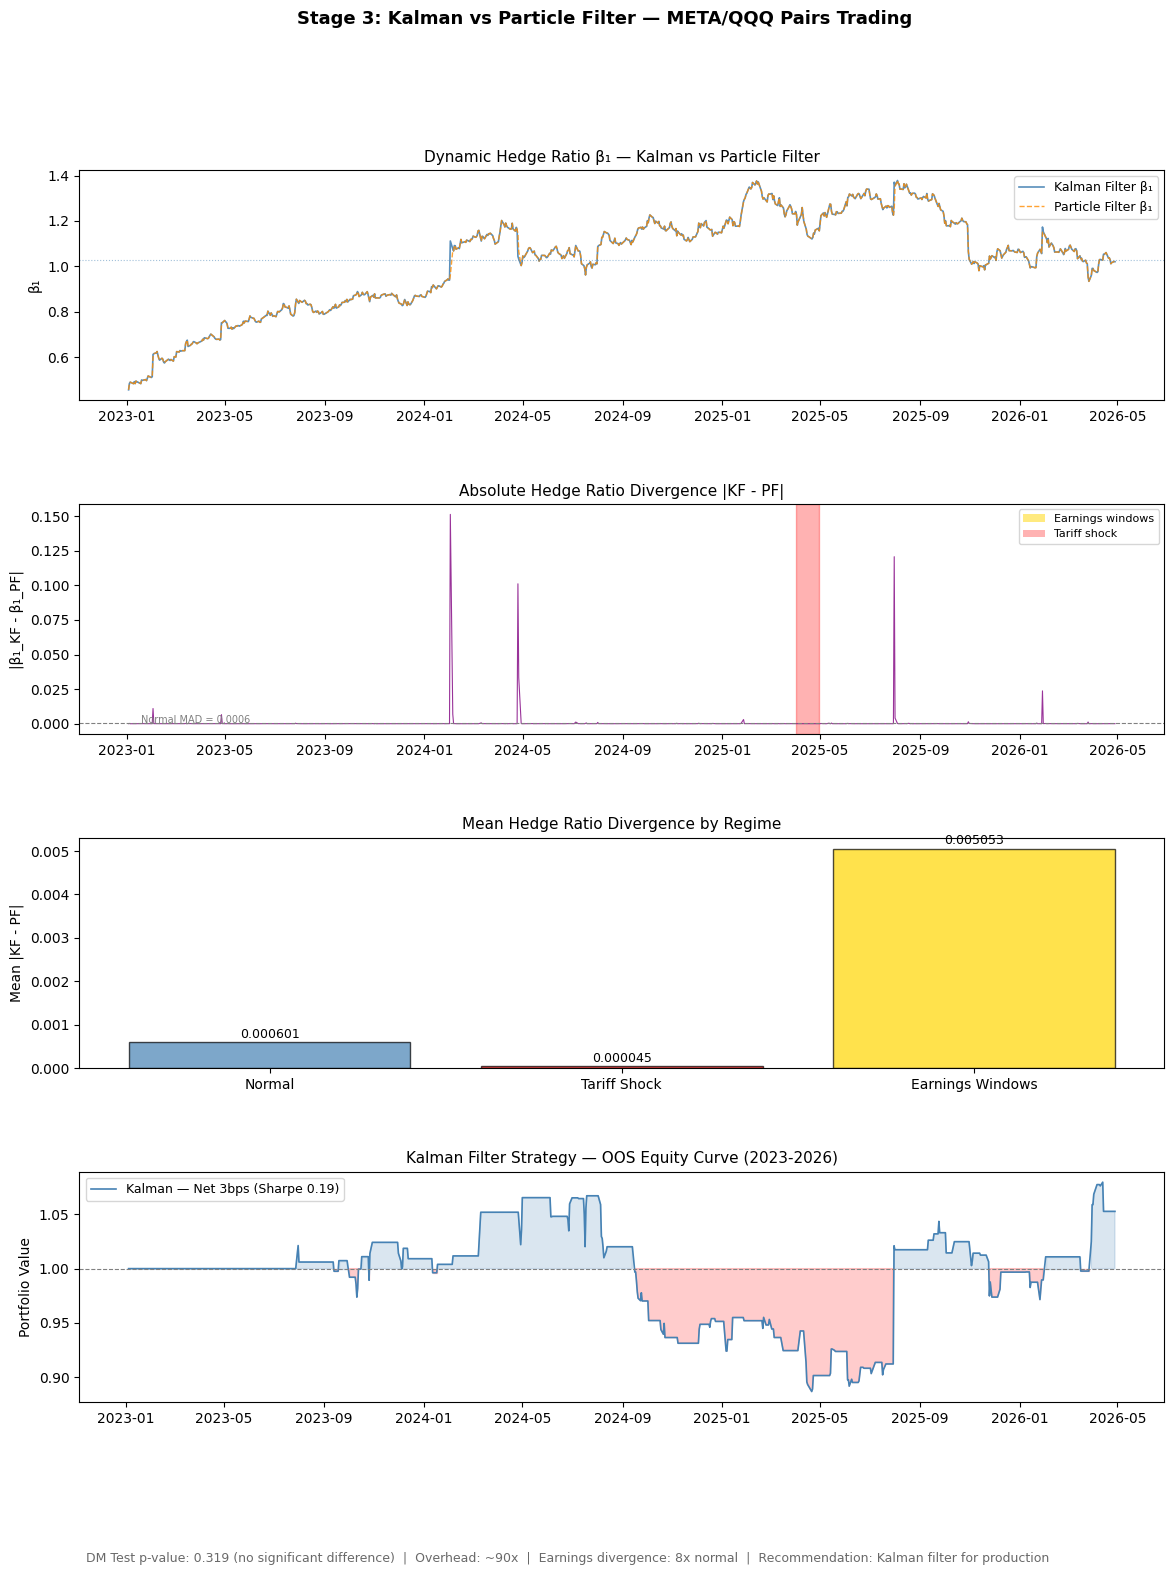

Saved — kalman_vs_particle_stage3.png


In [25]:
# =============================================================================
# CELL 11 — STAGE 3 VISUALISATION
# =============================================================================

fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

# --- Panel 1: Hedge Ratio Comparison ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(test.index, beta_kf_1d,
         color="steelblue", linewidth=1.2,
         label="Kalman Filter β₁", alpha=0.9)
ax1.plot(test.index, beta_pf_1d,
         color="darkorange", linewidth=1.0,
         linestyle="--", label="Particle Filter β₁", alpha=0.8)
ax1.axhline(beta_kf_1d.mean(), color="steelblue",
            linestyle=":", linewidth=0.8, alpha=0.5)
ax1.set_title("Dynamic Hedge Ratio β₁ — Kalman vs Particle Filter",
              fontsize=11)
ax1.set_ylabel("β₁")
ax1.legend(fontsize=9)

# --- Panel 2: Absolute Divergence with Regime Shading ---
ax2 = fig.add_subplot(gs[1])
divergence = diff_1d.abs()
ax2.plot(test.index, divergence,
         color="purple", linewidth=0.8, alpha=0.8)

# Shade earnings windows
for idx in test.index:
    if meta_earnings[test.index.get_loc(idx)]:
        ax2.axvspan(idx, idx, alpha=0.3, color="gold", linewidth=0)

# Shade tariff shock
tariff_dates = test.index[tariff_mask]
if len(tariff_dates) > 0:
    ax2.axvspan(tariff_dates[0], tariff_dates[-1],
                alpha=0.3, color="red", label="Tariff shock")

# Add dummy patches for legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="gold",  alpha=0.5, label="Earnings windows"),
    Patch(facecolor="red",   alpha=0.3, label="Tariff shock"),
]
ax2.legend(handles=legend_elements, fontsize=8)
ax2.set_title("Absolute Hedge Ratio Divergence |KF - PF|", fontsize=11)
ax2.set_ylabel("|β₁_KF - β₁_PF|")

# Add regime MAD annotations
ax2.axhline(0.000601, color="grey", linestyle="--",
            linewidth=0.8, label="Normal MAD")
ax2.text(test.index[10], 0.000601 + 0.0002,
         "Normal MAD = 0.0006", fontsize=7, color="grey")

# --- Panel 3: Regime Divergence Bar Chart ---
ax3 = fig.add_subplot(gs[2])
regimes     = ["Normal", "Tariff Shock", "Earnings Windows"]
mean_divs   = [0.000601, 0.000045, 0.005053]
colors      = ["steelblue", "red", "gold"]

bars = ax3.bar(regimes, mean_divs, color=colors, alpha=0.7, edgecolor="black")
ax3.set_title("Mean Hedge Ratio Divergence by Regime", fontsize=11)
ax3.set_ylabel("Mean |KF - PF|")

for bar, val in zip(bars, mean_divs):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0001,
             f"{val:.6f}", ha="center", fontsize=9)

# --- Panel 4: Kalman Backtest Equity Curve (Stage 2 result) ---
ax4 = fig.add_subplot(gs[3])

# Rerun clean Kalman backtest for plot
meta_ret_te = test["META"].pct_change()
qqq_ret_te  = test["QQQ"].pct_change()
beta_s_1d   = pd.Series(beta_kf_1d, index=test.index)
spread_ret_1d = (meta_ret_te - beta_s_1d * qqq_ret_te)

zscore_plot   = rolling_mad_zscore(
    pd.Series(meta_te - beta_kf_1d * qqq_te, index=test.index), 60
).clip(-4, 4)
thr_plot      = (1.5 * zscore_plot.rolling(20).std()).clip(0.5, 2.5)
sig_plot      = gen_signals(zscore_plot, thr_plot)
strat_plot    = (sig_plot.shift(1) * spread_ret_1d).dropna()

# Apply costs
tl_plot = []
sl      = sig_plot.shift(1).dropna()
cd, ce  = 0, None
for t in range(len(sl)):
    s = sl.iloc[t]
    if cd == 0 and s != 0:
        ce = t; cd = int(s)
    elif cd != 0 and s == 0:
        tl_plot.append((ce, t)); ce = None; cd = 0

cs_plot = pd.Series(0.0, index=strat_plot.index)
for eb, _ in tl_plot:
    if eb < len(cs_plot):
        cs_plot.iloc[eb] = 0.0003

net_plot = strat_plot - cs_plot
eq_plot  = (1 + net_plot).cumprod()
sh_plot  = (net_plot.mean() / net_plot.std()) * np.sqrt(252)

ax4.plot(eq_plot.index, eq_plot.values,
         color="steelblue", linewidth=1.2,
         label=f"Kalman — Net 3bps (Sharpe {sh_plot:.2f})")
ax4.axhline(1, color="grey", linestyle="--", linewidth=0.8)
ax4.fill_between(eq_plot.index, eq_plot.values, 1,
                 where=eq_plot.values >= 1,
                 alpha=0.2, color="steelblue")
ax4.fill_between(eq_plot.index, eq_plot.values, 1,
                 where=eq_plot.values < 1,
                 alpha=0.2, color="red")
ax4.set_title("Kalman Filter Strategy — OOS Equity Curve (2023-2026)",
              fontsize=11)
ax4.set_ylabel("Portfolio Value")
ax4.legend(fontsize=9)

# --- Footer ---
fig.text(
    0.13, 0.01,
    f"DM Test p-value: 0.319 (no significant difference)  |  "
    f"Overhead: ~90x  |  "
    f"Earnings divergence: 8x normal  |  "
    f"Recommendation: Kalman filter for production",
    fontsize=9, color="dimgrey"
)

plt.suptitle(
    "Stage 3: Kalman vs Particle Filter — META/QQQ Pairs Trading",
    fontsize=13, fontweight="bold"
)
plt.savefig("kalman_vs_particle_stage3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved — kalman_vs_particle_stage3.png")